# CARTS empirical experiments with Llama 3 8B

This notebook runs empirical explorations for a CARTS paper using Meta-Llama-3-8B-Instruct Q4_K_M GGUF through `llama-cpp-python`. CARTS means Contextual Autoregressive Rank Transcoding Steganography.

The protocol objects are:

- `R_c(x)`: autoregressive rank trace of token sequence `x` under context `c`.
- `G_c(r)`: autoregressive generator that emits the token with prescribed rank `r_i` under context `c`.
- `E_k(x) = G_k(R_empty(x))`: encoder.
- `D_k(y) = G_empty(R_k(y))`: decoder.
- `F_k(r) = R_empty(G_k(r))`: key-induced map on rank vectors.

The notebook saves all figures, tables, raw results, run manifests, and a paper-ready Markdown summary under `results/`. It does not prove steganographic security or insecurity; all claims are finite empirical statements under the specified model, tokenizer, key set, payload sample, and comparison distributions.


## 1. Imports and paths

This section imports the local utility module, creates result directories, and defines manifest helpers that record relative paths. Use the repository virtualenv-backed kernel if the system kernel lacks `numpy` or `llama_cpp`.


In [1]:
from pathlib import Path
import csv
import itertools
import json
import math
import os
import random
import statistics
import sys
import time
from collections import defaultdict

import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display, Markdown, Image
except ImportError:
    display = print
    Markdown = lambda text: text
    Image = None

NOTEBOOK_CWD = Path.cwd()
if (NOTEBOOK_CWD / "carts_empirical_utils.py").exists():
    EXP_DIR = NOTEBOOK_CWD
else:
    EXP_DIR = (NOTEBOOK_CWD / "paper-empirical-explorations").resolve()

if str(EXP_DIR) not in sys.path:
    sys.path.insert(0, str(EXP_DIR))

import carts_empirical_utils as cu

cu.ensure_dirs()
print("Experiment directory:", cu.relative_path(cu.EXPERIMENT_ROOT))
print("Figures:", cu.relative_path(cu.FIGURES_DIR))
print("Tables:", cu.relative_path(cu.TABLES_DIR))
print("Raw:", cu.relative_path(cu.RAW_DIR))
print("Text:", cu.relative_path(cu.TEXT_DIR))
print("Cache:", cu.relative_path(cu.CACHE_DIR))
print("Environment:", cu.environment_info())

FIGURE_MANIFEST = []
TABLE_MANIFEST = []
PAPER_BULLETS = []
EXPERIMENT_STATUS = {}
EXPERIMENT_RUNTIME_SECONDS = {}
RUN_NUMERIC_RESULTS = {}
RUN_STARTED_AT = time.perf_counter()
BUDGET_ADJUSTMENTS = []
PREVIOUS_RUN_MANIFEST = {}
PREVIOUS_RUN_CONFIG = {}


def elapsed_run_seconds():
    return time.perf_counter() - RUN_STARTED_AT


def record_figure(filename, experiment, caption_suggestion, paper_claim_supported):
    FIGURE_MANIFEST.append({
        "figure_file": f"results/figures/{filename}",
        "experiment": experiment,
        "caption_suggestion": caption_suggestion,
        "paper_claim_supported": paper_claim_supported,
    })


def record_table(filename, experiment, description, paper_claim_supported):
    TABLE_MANIFEST.append({
        "table_file": f"results/tables/{filename}",
        "experiment": experiment,
        "description": description,
        "paper_claim_supported": paper_claim_supported,
    })


def show_rows(rows, n=10):
    rows = list(rows)
    if pd is not None:
        display(pd.DataFrame(rows).head(n))
    else:
        display(rows[:n])


def mark_experiment(name, status, started_at, detail=""):
    elapsed = time.perf_counter() - started_at
    EXPERIMENT_RUNTIME_SECONDS[name] = elapsed
    EXPERIMENT_STATUS[name] = {
        "status": status,
        "runtime_seconds": elapsed,
        "detail": detail,
    }
    print(f"{name}: {status} in {elapsed:.1f}s {detail}")


Experiment directory: .
Figures: results/figures
Tables: results/tables
Raw: results/raw
Text: results/text
Cache: results/cache
Environment: {'python': '3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]', 'platform': 'Linux-6.17.0-22-generic-x86_64-with-glibc2.39', 'numpy': '2.3.5', 'sklearn_available': True, 'llama_cpp': '0.3.16', 'matplotlib': '3.10.7'}


## 2. Configuration

Four named run profiles are available. The notebook default is `paper_two_hour`, a larger-than-smoke profile intended to remain time-bounded on CPU. On CPU, Experiments 3 and 5 dominate because they repeatedly evaluate `F_k(r)` with full-vocabulary ranks. To override the profile without editing the notebook, launch nbconvert with `CARTS_RUN_PROFILE=smoke`, `CARTS_RUN_PROFILE=paper_two_hour`, or `CARTS_RUN_PROFILE=paper_medium`.

`paper_full` is defined for completeness but should not be run automatically.


In [2]:
CONFIG_PROFILES = {
    "smoke": {
        "quick_mode": True,
        "num_payloads": 8,
        "num_keys": 10,
        "num_payload_key_pairs": 8,
        "num_collision_payloads": 6,
        "num_stability_payloads": 8,
        "num_commutativity_pairs": 12,
        "num_commutativity_payloads": 6,
        "num_robustness_cases": 6,
        "num_shrinkage_true_keys": 1,
        "detector_bootstrap_samples": 200,
    },
    "paper_two_hour": {
        "quick_mode": False,
        "num_payloads": 24,
        "num_keys": 60,
        "num_payload_key_pairs": 40,
        "num_collision_payloads": 16,
        "num_stability_payloads": 16,
        "num_commutativity_pairs": 36,
        "num_commutativity_payloads": 8,
        "num_robustness_cases": 20,
        "num_shrinkage_true_keys": 3,
        "detector_bootstrap_samples": 300,
    },
    "paper_medium": {
        "quick_mode": False,
        "num_payloads": 40,
        "num_keys": 120,
        "num_payload_key_pairs": 80,
        "num_collision_payloads": 40,
        "num_stability_payloads": 30,
        "num_commutativity_pairs": 100,
        "num_commutativity_payloads": 20,
        "num_robustness_cases": 40,
        "num_shrinkage_true_keys": 3,
        "detector_bootstrap_samples": 1000,
    },
    "paper_full": {
        "quick_mode": False,
        "num_payloads": 100,
        "num_keys": 300,
        "num_payload_key_pairs": 200,
        "num_collision_payloads": 100,
        "num_stability_payloads": 50,
        "num_commutativity_pairs": 300,
        "num_commutativity_payloads": 30,
        "num_robustness_cases": 100,
        "num_shrinkage_true_keys": 5,
        "detector_bootstrap_samples": 1500,
    },
}

RUN_PROFILE = "paper_two_hour"
RUN_PROFILE = os.environ.get("CARTS_RUN_PROFILE", RUN_PROFILE)
if RUN_PROFILE not in CONFIG_PROFILES:
    raise ValueError(f"Unknown RUN_PROFILE {RUN_PROFILE!r}; choose one of {sorted(CONFIG_PROFILES)}")
if RUN_PROFILE == "paper_full" and os.environ.get("CARTS_ALLOW_PAPER_FULL") != "1":
    raise RuntimeError("paper_full is intentionally not run automatically. Set CARTS_ALLOW_PAPER_FULL=1 only for an explicit full run.")

MAX_RUNTIME_HOURS = float(os.environ.get("CARTS_MAX_RUNTIME_HOURS", "2.25"))
MAX_RUNTIME_SECONDS = MAX_RUNTIME_HOURS * 3600.0

previous_manifest_path = cu.RAW_DIR / "run_manifest.json"
previous_config_path = cu.RAW_DIR / "run_config.json"
if previous_manifest_path.exists():
    try:
        PREVIOUS_RUN_MANIFEST = cu.read_json(previous_manifest_path)
    except Exception as exc:
        PREVIOUS_RUN_MANIFEST = {"read_error": str(exc)}
if previous_config_path.exists():
    try:
        PREVIOUS_RUN_CONFIG = cu.read_json(previous_config_path).get("config", {})
    except Exception as exc:
        PREVIOUS_RUN_CONFIG = {"read_error": str(exc)}

CONFIG = {
    "run_profile": RUN_PROFILE,
    "model_key": "llama3_8b_q4_k_m",
    "secret_prefix": "",
    "random_seed": 123,
    "allow_failures": False,
    "n_ctx": 4096,
    "n_gpu_layers": 0,
    "n_threads": None,
    "tail_thresholds": [10, 100, 1000],
    "use_sklearn_detector": True,
    "use_embeddings": False,
    "comparison_distributions_used": ["carts", "ordinary_greedy", "ordinary_sampled"],
    "ordinary_sample_temperature": 0.8,
    "ordinary_sample_top_p": 0.95,
    "keep_cache_on_clear": True,
    "max_runtime_hours": MAX_RUNTIME_HOURS,
    "max_runtime_seconds": MAX_RUNTIME_SECONDS,
    "time_budget_adjustments": BUDGET_ADJUSTMENTS,
}
CONFIG.update(CONFIG_PROFILES[RUN_PROFILE])


def _previous_runtime(name):
    status = PREVIOUS_RUN_MANIFEST.get("experiment_status", {}).get(name, {})
    value = status.get("runtime_seconds")
    return float(value) if value is not None else None


def _estimate_from_previous(config):
    prev_cfg = PREVIOUS_RUN_CONFIG or {}
    prev_numeric = PREVIOUS_RUN_MANIFEST.get("numeric_results", {})
    old_k = int(prev_numeric.get("k_adm_size") or PREVIOUS_RUN_MANIFEST.get("size_of_finite_key_set_K_adm") or max(prev_cfg.get("num_keys", 1), 1))
    new_k = int(max(config.get("num_keys", 1), 31 if config.get("run_profile") == "smoke" else config.get("num_keys", 1)))
    components = {}

    def scaled(name, old_units, new_units):
        runtime = _previous_runtime(name)
        if runtime is None or old_units <= 0:
            return None
        return runtime * (new_units / old_units)

    components["experiment1_correctness"] = scaled(
        "experiment1_correctness",
        max(prev_cfg.get("num_payload_key_pairs", 0), 1),
        max(config.get("num_payload_key_pairs", 0), 1),
    )
    components["experiment2_rank_likelihood_detection"] = scaled(
        "experiment2_rank_likelihood_detection",
        max(prev_cfg.get("num_payload_key_pairs", 0), 1),
        max(config.get("num_payload_key_pairs", 0), 1),
    )
    components["experiment3_key_collision_fibers"] = scaled(
        "experiment3_key_collision_fibers",
        max(prev_cfg.get("num_collision_payloads", 0), 1) * old_k,
        max(config.get("num_collision_payloads", 0), 1) * new_k,
    )
    components["experiment4_collision_stability"] = scaled(
        "experiment4_collision_stability",
        max(prev_cfg.get("num_shrinkage_true_keys", 1), 1) * max(prev_cfg.get("num_stability_payloads", 0), 1) * old_k,
        max(config.get("num_shrinkage_true_keys", 1), 1) * max(config.get("num_stability_payloads", 0), 1) * new_k,
    )
    components["experiment5_noncommutativity"] = scaled(
        "experiment5_noncommutativity",
        max(prev_cfg.get("num_commutativity_pairs", 0), 1) * max(prev_cfg.get("num_commutativity_payloads", 0), 1),
        max(config.get("num_commutativity_pairs", 0), 1) * max(config.get("num_commutativity_payloads", 0), 1),
    )
    components["experiment6_robustness"] = scaled(
        "experiment6_robustness",
        max(prev_cfg.get("num_robustness_cases", 0), 1),
        max(config.get("num_robustness_cases", 0), 1),
    )
    usable = {key: value for key, value in components.items() if value is not None}
    return usable, sum(usable.values())


def _record_reduction(field, old_value, new_value, reason):
    if int(new_value) >= int(old_value):
        return
    CONFIG[field] = int(new_value)
    BUDGET_ADJUSTMENTS.append({
        "field": field,
        "old_value": int(old_value),
        "new_value": int(new_value),
        "reason": reason,
    })


def _apply_initial_time_budget(config):
    components, total_estimate = _estimate_from_previous(config)
    config["estimated_runtime_components_seconds_from_previous"] = components
    config["estimated_runtime_seconds_from_previous"] = total_estimate
    if not components or total_estimate <= config["max_runtime_seconds"]:
        return
    overflow = total_estimate - config["max_runtime_seconds"]
    exp5 = components.get("experiment5_noncommutativity", 0.0)
    exp6 = components.get("experiment6_robustness", 0.0)
    exp3 = components.get("experiment3_key_collision_fibers", 0.0)
    exp12 = components.get("experiment1_correctness", 0.0) + components.get("experiment2_rank_likelihood_detection", 0.0)

    if overflow > 0 and exp5 > 0:
        old = config["num_commutativity_pairs"]
        floor = min(old, 12)
        per_pair = exp5 / max(old, 1)
        new = max(floor, int(old - math.ceil(overflow / max(per_pair, 1e-9))))
        _record_reduction("num_commutativity_pairs", old, new, "initial smoke-based estimate exceeded time budget; reducing non-commutativity first")
        overflow = max(0.0, overflow - per_pair * (old - config["num_commutativity_pairs"]))

    if overflow > 0 and exp6 > 0:
        old = config["num_robustness_cases"]
        floor = min(old, 8)
        per_case = exp6 / max(old, 1)
        new = max(floor, int(old - math.ceil(overflow / max(per_case, 1e-9))))
        _record_reduction("num_robustness_cases", old, new, "initial smoke-based estimate exceeded time budget; reducing robustness second")
        overflow = max(0.0, overflow - per_case * (old - config["num_robustness_cases"]))

    if overflow > 0 and exp3 > 0:
        old = config["num_collision_payloads"]
        floor = min(old, 8)
        per_transcript = exp3 / max(old, 1)
        new = max(floor, int(old - math.ceil(overflow / max(per_transcript, 1e-9))))
        _record_reduction("num_collision_payloads", old, new, "initial smoke-based estimate exceeded time budget; reducing collision payloads third")
        overflow = max(0.0, overflow - per_transcript * (old - config["num_collision_payloads"]))

    if overflow > 0 and exp12 > 0:
        old = config["num_payload_key_pairs"]
        floor = min(old, 24)
        per_pair = exp12 / max(old, 1)
        new = max(floor, int(old - math.ceil(overflow / max(per_pair, 1e-9))))
        _record_reduction("num_payload_key_pairs", old, new, "initial smoke-based estimate exceeded time budget; reducing payload-key pairs last without going below 24")


_apply_initial_time_budget(CONFIG)
CONFIG["time_budget_adjustments"] = BUDGET_ADJUSTMENTS

random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

# The previous run was backed up before this notebook was executed. Clear stale
# tables/figures/raw/text while preserving expensive F_k cache files.
cu.clear_result_outputs(keep_cache=CONFIG["keep_cache_on_clear"])
cu.reset_summary("CARTS Empirical Summary")
config_markdown = f"""Profile: `{RUN_PROFILE}`

```json
{json.dumps(CONFIG, indent=2, sort_keys=True)}
```

Tokenization convention:

- {cu.TOKENIZATION_CONVENTION["prefix_context"]}
- {cu.TOKENIZATION_CONVENTION["payload_text"]}
- {cu.TOKENIZATION_CONVENTION["rank_order"]}
"""
cu.append_summary("Experimental configuration", config_markdown)
print(json.dumps(CONFIG, indent=2, sort_keys=True))
if BUDGET_ADJUSTMENTS:
    print("Time-budget adjustments:", json.dumps(BUDGET_ADJUSTMENTS, indent=2))


{
  "allow_failures": false,
  "comparison_distributions_used": [
    "carts",
    "ordinary_greedy",
    "ordinary_sampled"
  ],
  "detector_bootstrap_samples": 300,
  "estimated_runtime_components_seconds_from_previous": {
    "experiment1_correctness": 585.5478346100062,
    "experiment2_rank_likelihood_detection": 397.3086936849995,
    "experiment3_key_collision_fibers": 3632.4688289187106,
    "experiment4_collision_stability": 204.17655935612856,
    "experiment5_noncommutativity": 2363.310494452002,
    "experiment6_robustness": 677.7241549166683
  },
  "estimated_runtime_seconds_from_previous": 7860.536565938515,
  "keep_cache_on_clear": true,
  "max_runtime_hours": 2.25,
  "max_runtime_seconds": 8100.0,
  "model_key": "llama3_8b_q4_k_m",
  "n_ctx": 4096,
  "n_gpu_layers": 0,
  "n_threads": null,
  "num_collision_payloads": 16,
  "num_commutativity_pairs": 36,
  "num_commutativity_payloads": 8,
  "num_keys": 60,
  "num_payload_key_pairs": 40,
  "num_payloads": 24,
  "num_robus

## 3. Load Llama 3 8B model

The main model is `models/llama3_8b/Meta-Llama-3-8B-Instruct-Q4_K_M.gguf`. If it is missing, the loader raises a clear error and the full experiments are not run. The run uses CPU-safe defaults and full logits for rank computation.


In [3]:
started = time.perf_counter()
model_info = cu.MODEL_REGISTRY[CONFIG["model_key"]]
model_path = cu.REPO_ROOT / model_info["path"]
print("Model key:", CONFIG["model_key"])
print("Model description:", model_info["description"])
print("Expected model path:", model_info["path"])
print("Model file exists:", model_path.exists())

llm = cu.load_language_model(
    model_key=CONFIG["model_key"],
    n_threads=CONFIG["n_threads"],
    n_gpu_layers=CONFIG["n_gpu_layers"],
    n_ctx=CONFIG["n_ctx"],
    logits_all=True,
)

VOCAB_SIZE = cu.get_vocab_size(llm)
BOS_ID = cu.get_bos_id(llm)
EOS_ID = cu.get_eos_id(llm)
print("n_ctx:", CONFIG["n_ctx"])
print("logits_all:", True)
print("vocabulary size:", VOCAB_SIZE)
print("BOS token id:", BOS_ID)
print("EOS token id:", EOS_ID)

cu.save_manifest(CONFIG, cu.environment_info())
mark_experiment("model_load", "run", started)


Model key: llama3_8b_q4_k_m
Model description: Meta-Llama-3-8B-Instruct Q4_K_M GGUF
Expected model path: models/llama3_8b/Meta-Llama-3-8B-Instruct-Q4_K_M.gguf
Model file exists: True


llama_context: n_ctx_per_seq (4096) < n_ctx_train (8192) -- the full capacity of the model will not be utilized


n_ctx: 4096
logits_all: True
vocabulary size: 128256
BOS token id: 128000
EOS token id: 128001
model_load: run in 2.4s 


## 4. Payload and key sets

Payloads include at least 24 short factual, mundane, policy-like, neutral, longer, and repeated/simple sentences for the time-bounded profile. Keys include default examples, near-duplicate families, typo/deletion variants, punctuation variants, singular/plural variants, short suffix variants, templates over topic phrases, and optional prompts from `paper-empirical-explorations/data/key_prompts.txt`.

The Section 4 key table is limited by the selected profile. Experiment 3 uses the resulting finite set `K_adm`; for `paper_two_hour` the target size is at least 60 keys.


In [4]:
def make_payloads(target_count):
    base = [
        ("mundane sentence", "Switzerland is expensive."),
        ("factual sentence", "The meeting starts after lunch."),
        ("policy-like sentence", "The current policy has failed."),
        ("short sentence", "A quiet river crossed the valley."),
        ("longer sentence", "The lab notebook was hidden in the cabinet."),
        ("mundane sentence", "A small bird landed near the window."),
        ("factual sentence", "The archive contains several old records."),
        ("repeated simple payload", "The device stopped working after midnight."),
        ("factual sentence", "The old train station was closed."),
        ("mundane sentence", "A wooden box was placed under the desk."),
        ("model-like neutral sentence", "The report was delayed until morning."),
        ("mundane sentence", "Several people waited near the market."),
        ("mundane sentence", "The garden tools were left outside."),
        ("policy-like sentence", "The city council approved the plan."),
        ("factual sentence", "The weather changed before sunset."),
        ("longer sentence", "A narrow road followed the river."),
        ("factual sentence", "The museum opened after the storm."),
        ("model-like neutral sentence", "The machine failed during testing."),
        ("mundane sentence", "A notebook remained inside the drawer."),
        ("mundane sentence", "The village bakery closed early."),
        ("factual sentence", "The message was written in pencil."),
        ("policy-like sentence", "The committee rejected the proposal."),
        ("mundane sentence", "A quiet bird watched from the roof."),
        ("repeated simple payload", "The lights turned off after midnight."),
    ]
    rows = [{"category": cat, "text": text} for cat, text in base]
    corpus_path = cu.REPO_ROOT / "data" / "corpus.txt"
    if corpus_path.exists():
        words = corpus_path.read_text(encoding="utf-8").split()
        lengths = [8, 10, 12, 16, 20, 24]
        cursor = 0
        while len(rows) < target_count and cursor + max(lengths) < len(words):
            length = lengths[len(rows) % len(lengths)]
            span = " ".join(words[cursor:cursor + length])
            rows.append({"category": f"corpus_span_{length}_words", "text": span})
            cursor += length + 7
    idx = 0
    while len(rows) < target_count:
        rows.append({"category": "synthetic_sentence", "text": f"The archive record number {idx} stayed inside the quiet cabinet."})
        idx += 1
    return rows[:target_count]


def typo_variant(text):
    chars = list(text)
    for i, ch in enumerate(chars):
        if ch.isalpha():
            chars[i] = "x" if ch.lower() != "x" else "z"
            return "".join(chars)
    return text


def deletion_variant(text):
    tokens = text.split()
    if len(tokens) <= 1:
        return text
    return " ".join(tokens[:-1])


def plural_singular_variant(text):
    replacements = [
        ("roads", "road"),
        ("animals", "animal"),
        ("villages", "village"),
        ("descriptions", "description"),
        ("rivers", "river"),
        ("libraries", "library"),
        ("barrels", "barrel"),
        ("cellars", "cellar"),
        ("notebooks", "notebook"),
        ("stations", "station"),
        ("tools", "tool"),
    ]
    for src, dst in replacements:
        if src in text:
            return text.replace(src, dst)
        if dst in text:
            return text.replace(dst, src)
    return text + "s"


def punctuation_variants(text):
    stem = text.rstrip(".!?")
    return [stem + ".", stem + "!", stem + "?"]


def suffix_variants(text):
    stem = text.rstrip(".!?")
    return [stem + " today.", stem + " briefly.", stem + " in one paragraph."]


def build_admissible_key_records(target_size):
    default_keys = [
        "Write about baking bread.",
        "Describe a quiet mountain village.",
        "Talk about animals in a forest.",
        "Explain a baseball practice.",
        "Describe ancient Roman roads.",
        "Write a neutral product description.",
        "The quick brown fox jumps",
        "The quick brow fox jumps",
        "A wooden barrel sits in a cellar",
        "A wooden barrel sits in the cellar",
        "Flour is cheap",
        "Flour was cheap",
    ]
    records = []

    def add(key, category):
        key = key.strip()
        if key:
            records.append({"text": key, "category": category})

    for key in default_keys:
        add(key, "default_or_required_near_duplicate")
        add(typo_variant(key), "one_character_typo_variant")
        add(deletion_variant(key), "one_token_deletion_variant")
        add(plural_singular_variant(key), "plural_singular_variant")
        for variant in punctuation_variants(key):
            add(variant, "punctuation_variant")
        for variant in suffix_variants(key):
            add(variant, "short_suffix_variant")

    templates = [
        "Write about {topic}.",
        "Describe {topic}.",
        "Tell a story about {topic}.",
        "Explain {topic}.",
        "A paragraph about {topic}.",
        "A short note about {topic}.",
    ]
    topics = [
        "baking bread",
        "mountain villages",
        "forest animals",
        "baseball practice",
        "Roman roads",
        "product descriptions",
        "quiet rivers",
        "old libraries",
        "weather reports",
        "city markets",
        "wooden barrels",
        "cheese cellars",
        "laboratory notebooks",
        "train stations",
        "garden tools",
    ]
    for template in templates:
        for topic in topics:
            add(template.format(topic=topic), "template_key")

    optional_path = cu.EXPERIMENT_ROOT / "data" / "key_prompts.txt"
    if optional_path.exists():
        for line in optional_path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                add(line.strip(), "optional_key_prompts_file")

    deduped = []
    seen = set()
    for record in records:
        key = record["text"].strip()
        if key and key not in seen:
            seen.add(key)
            deduped.append({"text": key, "category": record["category"]})
    if len(deduped) < target_size:
        raise RuntimeError(f"K_adm construction produced only {len(deduped)} keys, below target {target_size}.")
    return deduped[:target_size]

payload_specs = make_payloads(CONFIG["num_payloads"])
key_target = max(CONFIG["num_keys"], 31 if RUN_PROFILE == "smoke" else CONFIG["num_keys"])
key_specs = build_admissible_key_records(key_target)
K_ADM = [record["text"] for record in key_specs]
CONFIG["k_adm_size"] = len(K_ADM)

payload_records = []
for idx, payload in enumerate(payload_specs):
    token_ids = cu.text_to_payload_ids(payload["text"], llm)
    payload_records.append({
        "payload_id": idx,
        "payload_text": payload["text"],
        "text": payload["text"],
        "category": payload["category"],
        "token_length": len(token_ids),
        "token_ids": token_ids,
    })

key_records = []
for idx, key in enumerate(key_specs):
    context_ids = cu._make_prefix_ids(key["text"], llm)
    key_records.append({
        "key_id": idx,
        "key_text": key["text"],
        "text": key["text"],
        "key_category": key["category"],
        "category": key["category"],
        "token_length": len(context_ids),
        "context_token_length": len(context_ids),
        "context_ids": context_ids,
    })

cu.write_csv(cu.TABLES_DIR / "payloads.csv", payload_records)
cu.write_csv(cu.TABLES_DIR / "keys.csv", key_records)
record_table("payloads.csv", "Section 4", "Payload set and token lengths for this run.", "Defines tested payload distribution.")
record_table("keys.csv", "Section 4", "Finite key set and context token lengths for this run.", "Defines tested finite key set.")
print("Payloads:", len(payload_records), "K_adm:", len(K_ADM))
show_rows([{k: v for k, v in row.items() if k != "token_ids"} for row in payload_records])
show_rows([{k: v for k, v in row.items() if k != "context_ids"} for row in key_records])


Payloads: 24 K_adm: 60


[{'payload_id': 0,
  'payload_text': 'Switzerland is expensive.',
  'text': 'Switzerland is expensive.',
  'category': 'mundane sentence',
  'token_length': 4},
 {'payload_id': 1,
  'payload_text': 'The meeting starts after lunch.',
  'text': 'The meeting starts after lunch.',
  'category': 'factual sentence',
  'token_length': 6},
 {'payload_id': 2,
  'payload_text': 'The current policy has failed.',
  'text': 'The current policy has failed.',
  'category': 'policy-like sentence',
  'token_length': 6},
 {'payload_id': 3,
  'payload_text': 'A quiet river crossed the valley.',
  'text': 'A quiet river crossed the valley.',
  'category': 'short sentence',
  'token_length': 7},
 {'payload_id': 4,
  'payload_text': 'The lab notebook was hidden in the cabinet.',
  'text': 'The lab notebook was hidden in the cabinet.',
  'category': 'longer sentence',
  'token_length': 9},
 {'payload_id': 5,
  'payload_text': 'A small bird landed near the window.',
  'text': 'A small bird landed near the win

[{'key_id': 0,
  'key_text': 'Write about baking bread.',
  'text': 'Write about baking bread.',
  'key_category': 'default_or_required_near_duplicate',
  'category': 'default_or_required_near_duplicate',
  'token_length': 5,
  'context_token_length': 5},
 {'key_id': 1,
  'key_text': 'xrite about baking bread.',
  'text': 'xrite about baking bread.',
  'key_category': 'one_character_typo_variant',
  'category': 'one_character_typo_variant',
  'token_length': 6,
  'context_token_length': 6},
 {'key_id': 2,
  'key_text': 'Write about baking',
  'text': 'Write about baking',
  'key_category': 'one_token_deletion_variant',
  'category': 'one_token_deletion_variant',
  'token_length': 3,
  'context_token_length': 3},
 {'key_id': 3,
  'key_text': 'Write about baking bread.s',
  'text': 'Write about baking bread.s',
  'key_category': 'plural_singular_variant',
  'category': 'plural_singular_variant',
  'token_length': 5,
  'context_token_length': 5},
 {'key_id': 4,
  'key_text': 'Write about 

## 5. Smoke test

This single example checks the token-id-level CARTS round trip before any empirical interpretation. If exact recovery fails and `allow_failures=False`, execution stops.


In [5]:
started = time.perf_counter()
smoke_payload = payload_records[0]
smoke_key = key_records[0]
encoded = cu.E_key_token_ids(llm, smoke_payload["token_ids"], smoke_key["text"], CONFIG["secret_prefix"])
decoded = cu.D_key_token_ids(llm, encoded["stegotext_ids"], smoke_key["text"], CONFIG["secret_prefix"])
exact = cu.exact_match(decoded["decoded_ids"], smoke_payload["token_ids"])
print("Payload:", smoke_payload["text"])
print("Key:", smoke_key["text"])
print("Payload token IDs:", smoke_payload["token_ids"])
print("Ranks:", encoded["ranks"])
print("Stegotext:", encoded["stegotext_text"])
print("Decoded text:", decoded["decoded_text"])
print("Exact token match:", exact)

cu.write_json(cu.RAW_DIR / "smoke_test.json", {
    "payload": smoke_payload["text"],
    "key": smoke_key["text"],
    "payload_token_ids": smoke_payload["token_ids"],
    "ranks": encoded["ranks"],
    "stegotext_ids": encoded["stegotext_ids"],
    "decoded_ids": decoded["decoded_ids"],
    "exact_token_match": exact,
})
mark_experiment("smoke_test", "run" if exact else "failed", started)
if not exact and not CONFIG["allow_failures"]:
    raise RuntimeError("Smoke test failed. Stop before interpreting experiments.")


Payload: Switzerland is expensive.
Key: Write about baking bread.
Payload token IDs: [30221, 374, 11646, 13]
Ranks: [74364, 3, 435, 2]
Stegotext:  Porno
Anybody
Decoded text:  Switzerland is expensive.
Exact token match: True
smoke_test: run in 5.9s 


# Experiment 1: Implementation correctness

This validates the implementation of `D_k(E_k(x)) = x` and the reverse check on encoded stegotexts. Exact token-id equality is the pass condition. The table records token lengths and Wilson confidence intervals for the run-level success rates.


experiment1_correctness: run in 607.6s 


[{'case_id': 0,
  'payload_id': 11,
  'key_id': 26,
  'payload_category': 'mundane sentence',
  'payload_text': 'Several people waited near the market.',
  'key_text': 'Talk about animals in a forest in one paragraph.',
  'payload_token_length': 7,
  'decode_exact_token_match': True,
  'reverse_exact_token_match': True,
  'display_string_match': True,
  'first_mismatch_position': None,
  'stegotext_text': ' browse this timeline from the chimpanpan',
  'decoded_text': ' Several people waited near the market.',
  'decode_success_rate': 1.0,
  'decode_wilson95_low': 0.9123783988027135,
  'decode_wilson95_high': 1.0,
  'reverse_success_rate': 1.0,
  'reverse_wilson95_low': 0.9123783988027135,
  'reverse_wilson95_high': 1.0},
 {'case_id': 1,
  'payload_id': 22,
  'key_id': 30,
  'payload_category': 'mundane sentence',
  'payload_text': 'A quiet bird watched from the roof.',
  'key_text': 'Explain a baseball practice.s',
  'payload_token_length': 8,
  'decode_exact_token_match': True,
  'rev

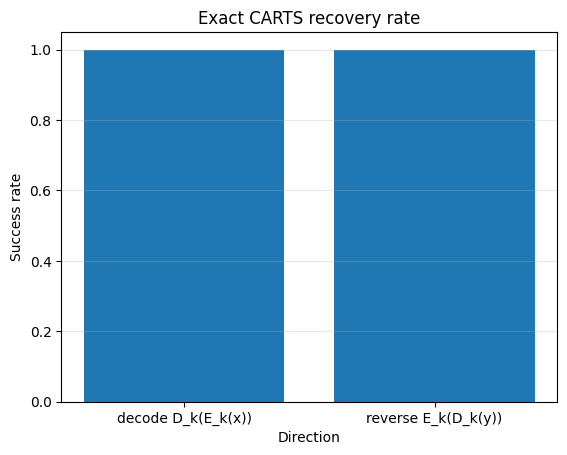

In [6]:
started = time.perf_counter()

def sampled_payload_key_pairs(limit):
    pairs = list(itertools.product(payload_records, key_records))
    rng = random.Random(CONFIG["random_seed"])
    rng.shuffle(pairs)
    return pairs[:limit]

exp1_rows = []
for case_id, (payload, key) in enumerate(sampled_payload_key_pairs(CONFIG["num_payload_key_pairs"])):
    encoded = cu.E_key_token_ids(llm, payload["token_ids"], key["text"], CONFIG["secret_prefix"])
    decoded = cu.D_key_token_ids(llm, encoded["stegotext_ids"], key["text"], CONFIG["secret_prefix"])
    decode_exact = cu.exact_match(decoded["decoded_ids"], payload["token_ids"])
    reencoded = cu.E_key_token_ids(llm, decoded["decoded_ids"], key["text"], CONFIG["secret_prefix"])
    reverse_exact = cu.exact_match(reencoded["stegotext_ids"], encoded["stegotext_ids"])
    exp1_rows.append({
        "case_id": case_id,
        "payload_id": payload["payload_id"],
        "key_id": key["key_id"],
        "payload_category": payload["category"],
        "payload_text": payload["text"],
        "key_text": key["text"],
        "payload_token_length": len(payload["token_ids"]),
        "decode_exact_token_match": decode_exact,
        "reverse_exact_token_match": reverse_exact,
        "display_string_match": decoded["decoded_text"].strip() == payload["text"].strip(),
        "first_mismatch_position": cu.first_mismatch_position(decoded["decoded_ids"], payload["token_ids"]),
        "stegotext_text": encoded["stegotext_text"],
        "decoded_text": decoded["decoded_text"],
    })

num_cases = len(exp1_rows)
decode_success = sum(row["decode_exact_token_match"] for row in exp1_rows)
reverse_success = sum(row["reverse_exact_token_match"] for row in exp1_rows)
decode_ci = cu.wilson_interval(decode_success, num_cases)
reverse_ci = cu.wilson_interval(reverse_success, num_cases)
for row in exp1_rows:
    row.update({
        "decode_success_rate": decode_success / max(num_cases, 1),
        "decode_wilson95_low": decode_ci[0],
        "decode_wilson95_high": decode_ci[1],
        "reverse_success_rate": reverse_success / max(num_cases, 1),
        "reverse_wilson95_low": reverse_ci[0],
        "reverse_wilson95_high": reverse_ci[1],
    })

cu.write_csv(cu.TABLES_DIR / "experiment1_correctness.csv", exp1_rows)
cu.write_json(cu.RAW_DIR / "experiment1_correctness.json", exp1_rows)
record_table("experiment1_correctness.csv", "Experiment 1", "Round-trip status for each payload-key pair with Wilson intervals.", "Exact invertibility implementation check.")

cu.bar_plot(
    ["decode D_k(E_k(x))", "reverse E_k(D_k(y))"],
    [decode_success / max(num_cases, 1), reverse_success / max(num_cases, 1)],
    "exp1_correctness_bar.png",
    "Exact CARTS recovery rate",
    "Direction",
    "Success rate",
)
record_figure("exp1_correctness_bar.png", "Experiment 1", "Exact token-id recovery rates for decode and reverse directions.", "Exact invertibility on tested samples.")

failure_positions = [row["first_mismatch_position"] for row in exp1_rows if row["first_mismatch_position"] is not None]
if failure_positions:
    cu.histogram(failure_positions, "exp1_mismatch_positions.png", "First mismatch positions for failed round trips", "First mismatch token position")
    record_figure("exp1_mismatch_positions.png", "Experiment 1", "First mismatch positions for failed CARTS round trips.", "Implementation debugging only.")

summary = (
    f"Exact recovery succeeded in {decode_success}/{num_cases} payload-key pairs "
    f"(rate {decode_success / max(num_cases, 1):.3f}, Wilson 95% CI [{decode_ci[0]:.3f}, {decode_ci[1]:.3f}]). "
    f"Reverse-direction recovery succeeded in {reverse_success}/{num_cases} cases "
    f"(rate {reverse_success / max(num_cases, 1):.3f}, Wilson 95% CI [{reverse_ci[0]:.3f}, {reverse_ci[1]:.3f}]). "
    "This verifies the implementation under the specified deterministic environment; the theorem itself is mathematical."
)
PAPER_BULLETS.append(summary)
RUN_NUMERIC_RESULTS.update({
    "correctness_successes": decode_success,
    "correctness_total": num_cases,
    "reverse_successes": reverse_success,
    "reverse_total": num_cases,
})
cu.append_summary("Implementation correctness result", summary)
mark_experiment("experiment1_correctness", "run", started)
show_rows(exp1_rows)
if decode_success != num_cases and not CONFIG["allow_failures"]:
    raise RuntimeError("Experiment 1 failed exact token recovery. Stop before interpreting downstream results.")


# Experiment 2: Rank-likelihood, rank-trace statistics, and simple detection

This compares CARTS outputs against two ordinary comparison distributions under the same key context and exact token length: greedy generation (`Q_greedy`) and fixed-seed nucleus sampling (`Q_sampled`, temperature 0.8, top-p 0.95). Greedy is a weak baseline; sampled is more realistic but still not a full cover-channel model.


experiment2_rank_likelihood_detection: run in 423.3s 


[{'case_id': 0,
  'comparison_distribution': 'carts',
  'payload_id': 11,
  'key_id': 26,
  'payload_text': 'Several people waited near the market.',
  'key_text': 'Talk about animals in a forest in one paragraph.',
  'token_length': 7,
  'normalized_nll': 8.027539403923653,
  'mean_log_rank': 4.1021822204059735,
  'max_log_rank': 10.34971065311646,
  'generated_text': ' browse this timeline from the chimpanpan',
  'ranks': [31248, 10, 467, 15, 1, 193, 7],
  'tail_rank_fraction_gt_10': 0.5714285714285714,
  'tail_rank_fraction_gt_100': 0.42857142857142855,
  'tail_rank_fraction_gt_1000': 0.14285714285714285},
 {'case_id': 0,
  'comparison_distribution': 'ordinary_greedy',
  'payload_id': 11,
  'key_id': 26,
  'payload_text': 'Several people waited near the market.',
  'key_text': 'Talk about animals in a forest in one paragraph.',
  'token_length': 7,
  'normalized_nll': 0.6094869216278299,
  'mean_log_rank': 0.0,
  'max_log_rank': 0.0,
  'generated_text': ' The forest is home to many 

[{'comparison': 'carts_vs_ordinary_greedy',
  'auc': 1.0,
  'auc_bootstrap95_low': 1.0,
  'auc_bootstrap95_high': 1.0,
  'detector_note': 'sklearn logistic regression detector trained on a small split.'},
 {'comparison': 'carts_vs_ordinary_sampled',
  'auc': 1.0,
  'auc_bootstrap95_low': 0.9999999999999999,
  'auc_bootstrap95_high': 1.0,
  'detector_note': 'sklearn logistic regression detector trained on a small split.'}]

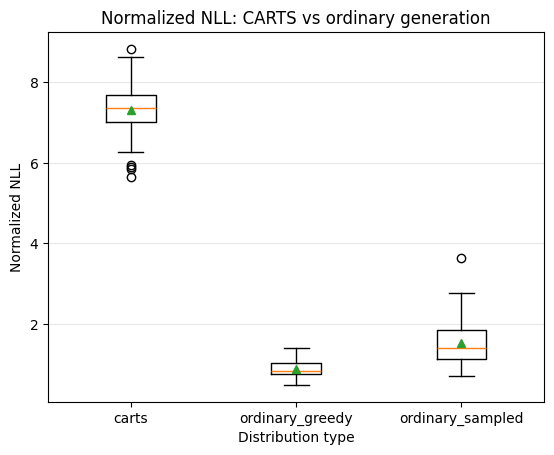

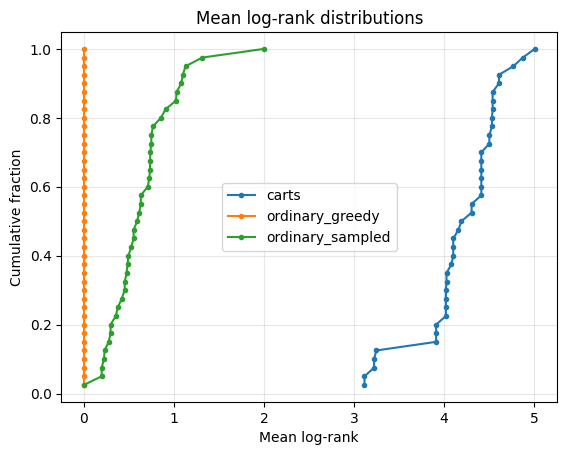

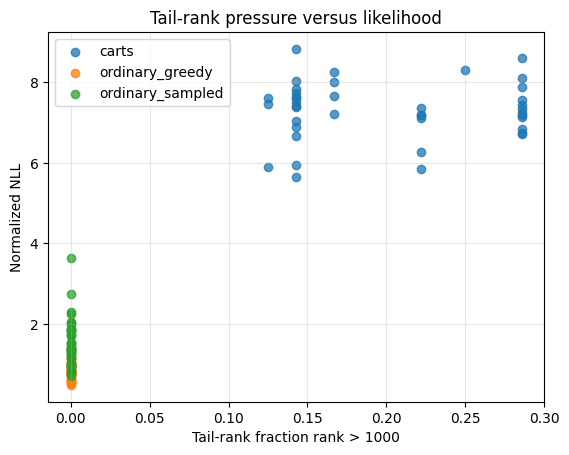

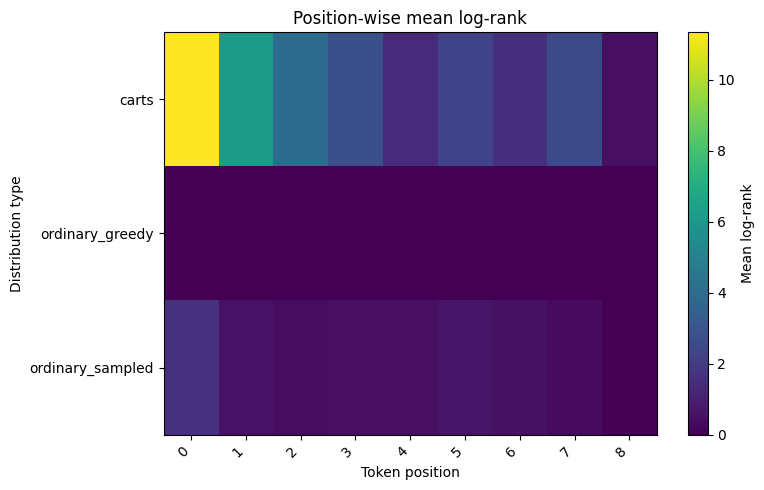

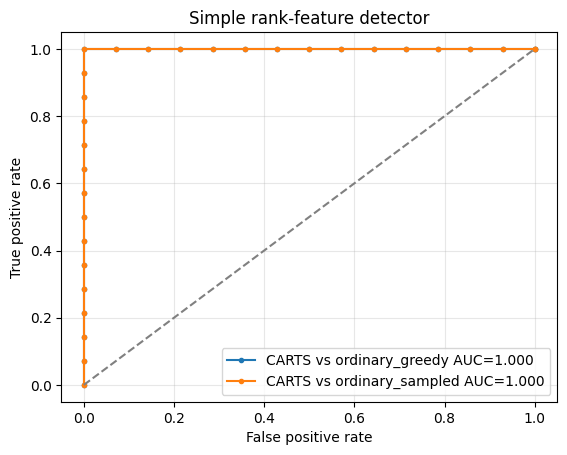

In [7]:
started = time.perf_counter()
exp2_rows = []
positionwise = defaultdict(list)

def add_trace_row(case_id, label, payload, key, ranks, nll, generated_ids, generated_text):
    row = {
        "case_id": case_id,
        "comparison_distribution": label,
        "payload_id": payload["payload_id"],
        "key_id": key["key_id"],
        "payload_text": payload["text"],
        "key_text": key["text"],
        "token_length": len(generated_ids),
        "normalized_nll": nll,
        "mean_log_rank": cu.mean_log_rank(ranks),
        "max_log_rank": cu.max_log_rank(ranks),
        "generated_text": generated_text,
        "ranks": ranks,
    }
    for B in CONFIG["tail_thresholds"]:
        row[f"tail_rank_fraction_gt_{B}"] = cu.tail_rank_fraction(ranks, B)
    exp2_rows.append(row)
    positionwise[label].append([math.log(max(int(rank), 1)) for rank in ranks])

for case_id, (payload, key) in enumerate(sampled_payload_key_pairs(CONFIG["num_payload_key_pairs"])):
    n = len(payload["token_ids"])
    encoded = cu.E_key_token_ids(llm, payload["token_ids"], key["text"], CONFIG["secret_prefix"])
    add_trace_row(case_id, "carts", payload, key, encoded["ranks"], encoded["stegotext_generation"]["normalized_nll"], encoded["stegotext_ids"], encoded["stegotext_text"])

    greedy = cu.ordinary_greedy_generation(llm, key["text"], n, CONFIG["secret_prefix"])
    add_trace_row(case_id, "ordinary_greedy", payload, key, greedy["ranks"], greedy["normalized_nll"], greedy["generated_ids"], greedy["generated_text"])

    sampled = cu.ordinary_sample_generation(
        llm,
        key["text"],
        n,
        CONFIG["secret_prefix"],
        temperature=CONFIG["ordinary_sample_temperature"],
        top_p=CONFIG["ordinary_sample_top_p"],
        seed=CONFIG["random_seed"] + case_id,
    )
    add_trace_row(case_id, "ordinary_sampled", payload, key, sampled["ranks"], sampled["normalized_nll"], sampled["generated_ids"], sampled["generated_text"])

cu.write_csv(cu.TABLES_DIR / "experiment2_rank_likelihood_detection.csv", exp2_rows)
cu.write_json(cu.RAW_DIR / "experiment2_rank_likelihood_detection.json", exp2_rows)
record_table("experiment2_rank_likelihood_detection.csv", "Experiment 2", "Rank-likelihood features for CARTS, greedy, and sampled comparison text.", "Rank pressure and distribution-specific detectability.")

nll_by_dist = defaultdict(list)
mean_log_by_dist = defaultdict(list)
for row in exp2_rows:
    nll_by_dist[row["comparison_distribution"]].append(row["normalized_nll"])
    mean_log_by_dist[row["comparison_distribution"]].append(row["mean_log_rank"])

cu.boxplot(nll_by_dist, "exp2_nll_boxplot.png", "Normalized NLL: CARTS vs ordinary generation", "Normalized NLL", "Distribution type")
record_figure("exp2_nll_boxplot.png", "Experiment 2", "Normalized NLL for CARTS, greedy, and sampled ordinary comparisons.", "Rank-likelihood behavior under comparison distributions.")
cu.empirical_cdf(mean_log_by_dist, "exp2_mean_log_rank_cdf.png", "Mean log-rank distributions", "Mean log-rank")
record_figure("exp2_mean_log_rank_cdf.png", "Experiment 2", "Mean log-rank CDF for CARTS, greedy, and sampled traces.", "Rank-trace distribution shift.")
primary_B = CONFIG["tail_thresholds"][-1]
cu.scatter_plot(
    [row[f"tail_rank_fraction_gt_{primary_B}"] for row in exp2_rows],
    [row["normalized_nll"] for row in exp2_rows],
    "exp2_tail_rank_vs_nll.png",
    "Tail-rank pressure versus likelihood",
    f"Tail-rank fraction rank > {primary_B}",
    "Normalized NLL",
    labels=[row["comparison_distribution"] for row in exp2_rows],
)
record_figure("exp2_tail_rank_vs_nll.png", "Experiment 2", "Tail-rank fraction versus normalized NLL by distribution type.", "Rank pressure and likelihood relationship.")

order = ["carts", "ordinary_greedy", "ordinary_sampled"]
max_len = max(len(seq) for values in positionwise.values() for seq in values)
heat_rows = []
for label in order:
    arr = np.full((len(positionwise[label]), max_len), np.nan)
    for i, seq in enumerate(positionwise[label]):
        arr[i, :len(seq)] = seq
    heat_rows.append(np.nanmean(arr, axis=0).tolist())
cu.heatmap(heat_rows, "exp2_positionwise_mean_log_rank_heatmap.png", "Position-wise mean log-rank", "Token position", "Distribution type", xticklabels=[str(i) for i in range(max_len)], yticklabels=order, colorbar_label="Mean log-rank")
record_figure("exp2_positionwise_mean_log_rank_heatmap.png", "Experiment 2", "Position-wise mean log-rank for CARTS and ordinary baselines.", "Position-wise rank pressure.")

feature_columns = ["normalized_nll", "mean_log_rank", "max_log_rank", "token_length"] + [f"tail_rank_fraction_gt_{B}" for B in CONFIG["tail_thresholds"]]
detector_rows = []
roc_plot_rows = []
for baseline in ["ordinary_greedy", "ordinary_sampled"]:
    subset = [row for row in exp2_rows if row["comparison_distribution"] in ["carts", baseline]]
    features = [[row[col] for col in feature_columns] for row in subset]
    labels = [1 if row["comparison_distribution"] == "carts" else 0 for row in subset]
    detector = cu.train_simple_logistic_regression(features, labels, CONFIG["random_seed"])
    if not detector["available"]:
        scores = [row["normalized_nll"] for row in subset]
        auc = cu.roc_auc_score(labels, scores)
        detector.update({"auc": auc, "scores": scores, "labels": labels, "note": detector["note"] + " Fallback AUC uses normalized NLL only."})
    ci = cu.bootstrap_auc_ci(detector["labels"], detector["scores"], CONFIG["detector_bootstrap_samples"], CONFIG["random_seed"])
    detector_rows.append({
        "comparison": f"carts_vs_{baseline}",
        "auc": detector["auc"],
        "auc_bootstrap95_low": ci[0],
        "auc_bootstrap95_high": ci[1],
        "detector_note": detector.get("note", ""),
    })
    roc_plot_rows.append((baseline, detector["labels"], detector["scores"], detector["auc"]))

# Multi-curve ROC plot.
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for baseline, labels, scores, auc in roc_plot_rows:
    pairs = sorted(zip(scores, labels), key=lambda item: item[0], reverse=True)
    positives = sum(1 for label in labels if int(label) == 1)
    negatives = sum(1 for label in labels if int(label) == 0)
    tp = 0
    fp = 0
    fpr = [0.0]
    tpr = [0.0]
    for _, label in pairs:
        if int(label) == 1:
            tp += 1
        else:
            fp += 1
        tpr.append(tp / max(positives, 1))
        fpr.append(fp / max(negatives, 1))
    fpr.append(1.0)
    tpr.append(1.0)
    ax.plot(fpr, tpr, marker=".", label=f"CARTS vs {baseline} AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("Simple rank-feature detector")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(cu.FIGURES_DIR / "exp2_detector_roc.png", dpi=200, bbox_inches="tight")
record_figure("exp2_detector_roc.png", "Experiment 2", "ROC curves for CARTS versus greedy and sampled comparison distributions.", "Distribution-specific simple detectability.")

cu.write_csv(cu.TABLES_DIR / "experiment2_detector_auc.csv", detector_rows)
cu.write_json(cu.RAW_DIR / "experiment2_detector.json", detector_rows)
record_table("experiment2_detector_auc.csv", "Experiment 2", "Detector AUCs and bootstrap confidence intervals.", "Distribution-specific simple detectability.")

means = {dist: statistics.mean(vals) for dist, vals in nll_by_dist.items()}
auc_text = "; ".join(f"{row['comparison']} AUC {row['auc']:.3f} [{row['auc_bootstrap95_low']:.3f}, {row['auc_bootstrap95_high']:.3f}]" for row in detector_rows)
summary = (
    f"Mean normalized NLL was CARTS {means['carts']:.4f}, greedy {means['ordinary_greedy']:.4f}, and sampled {means['ordinary_sampled']:.4f}. "
    f"Detector results: {auc_text}. Greedy comparison is a weak baseline; sampled comparison is more realistic but still not a full cover-channel model. "
    "The tested CARTS outputs were separable from the chosen comparison distribution under the tested features; this is not a proof of steganographic insecurity."
)
PAPER_BULLETS.append(summary)
RUN_NUMERIC_RESULTS.update({
    "carts_mean_nll": means["carts"],
    "greedy_mean_nll": means["ordinary_greedy"],
    "sampled_mean_nll": means["ordinary_sampled"],
    "detector_auc_rows": detector_rows,
})
cu.append_summary("Rank-likelihood and detection result", summary)
mark_experiment("experiment2_rank_likelihood_detection", "run", started)
show_rows(exp2_rows)
show_rows(detector_rows)


# Experiment 3: Key-collision fiber census and finite key search

For each sampled payload rank vector and a true key from finite `K_adm`, this enumerates every key in `K_adm` and computes the candidate fiber `{k in K_adm : F_k(r) = w}`. Any collision is verified by recomputing without cache. If no collisions are found, that is reported as a finite negative search result, not a statement about unrestricted prompt space.


experiment3_key_collision_fibers: run in 3727.7s 


[{'case_id': 0,
  'payload_id': 0,
  'payload_text': 'Switzerland is expensive.',
  'rank_length': 4,
  'true_key': 'Write about baking bread.',
  'fiber_size': 1,
  'candidate_keys': ['Write about baking bread.'],
  'true_key_in_candidates': True,
  'collisions_verified_without_cache': True,
  'keyset_size': 60,
  'f_evaluations': 60,
  'search_elapsed_seconds': 100.6383072940007,
  'collision_rate': 0.0,
  'collision_wilson95_low': 0.0,
  'collision_wilson95_high': 0.1936076805344365,
  'true_key_containment_rate': 1.0,
  'true_key_containment_wilson95_low': 0.8063923194655637,
  'true_key_containment_wilson95_high': 1.0},
 {'case_id': 1,
  'payload_id': 1,
  'payload_text': 'The meeting starts after lunch.',
  'rank_length': 6,
  'true_key': 'xrite about baking bread.',
  'fiber_size': 1,
  'candidate_keys': ['xrite about baking bread.'],
  'true_key_in_candidates': True,
  'collisions_verified_without_cache': True,
  'keyset_size': 60,
  'f_evaluations': 60,
  'search_elapsed_secon

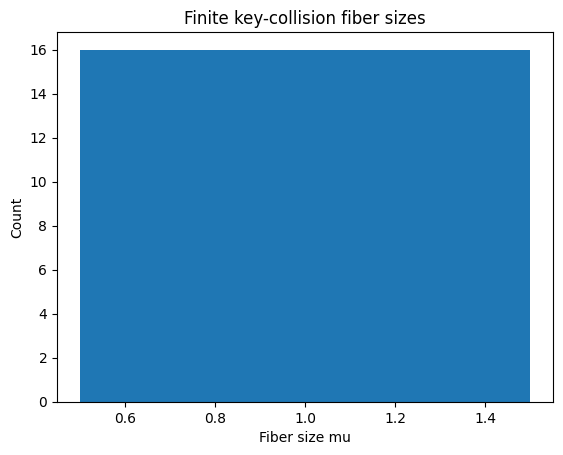

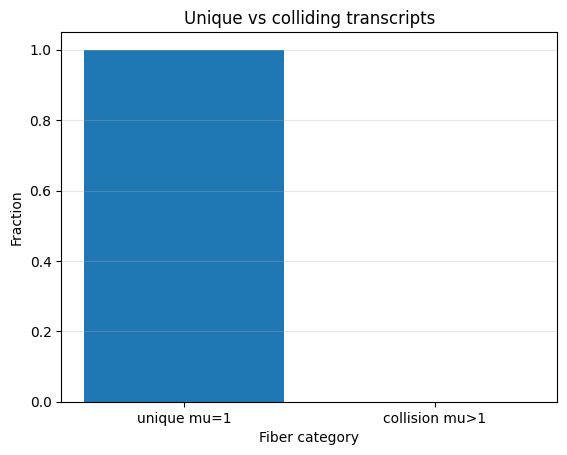

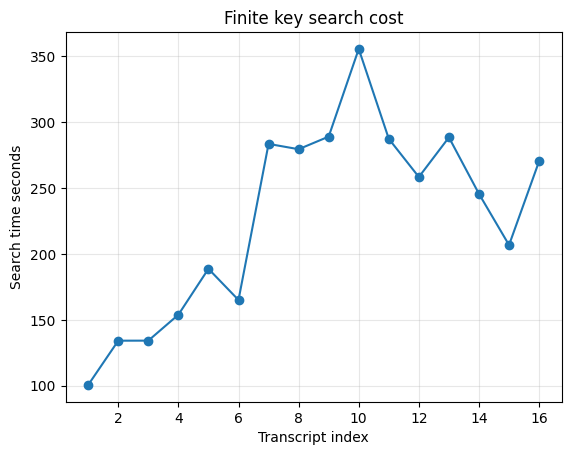

In [8]:
started = time.perf_counter()
collision_payloads = payload_records[:CONFIG["num_collision_payloads"]]
exp3_rows = []
largest_rows = []
collision_pairs = []
search_cost_rows = []

for case_id, payload in enumerate(collision_payloads):
    rank_trace = cu.rank_trace_from_token_ids(llm, cu._make_prefix_ids(CONFIG["secret_prefix"], llm), payload["token_ids"])
    ranks = rank_trace["ranks"]
    true_key = K_ADM[case_id % len(K_ADM)]
    w_true = cu.F_key_on_ranks(ranks, true_key, llm, CONFIG["secret_prefix"], use_cache=True)
    t0 = time.perf_counter()
    candidates = []
    for candidate_key in K_ADM:
        if cu.F_key_on_ranks(ranks, candidate_key, llm, CONFIG["secret_prefix"], use_cache=True) == w_true:
            candidates.append(candidate_key)
    elapsed = time.perf_counter() - t0
    verified = True
    if len(candidates) > 1:
        for candidate_key in candidates:
            verified = verified and (cu.F_key_on_ranks(ranks, candidate_key, llm, CONFIG["secret_prefix"], use_cache=False) == w_true)
        for a, b in itertools.combinations(candidates, 2):
            collision_pairs.append({"payload_id": payload["payload_id"], "payload_text": payload["text"], "rank_length": len(ranks), "key_a": a, "key_b": b, "ranks": ranks, "w": w_true})
    row = {
        "case_id": case_id,
        "payload_id": payload["payload_id"],
        "payload_text": payload["text"],
        "rank_length": len(ranks),
        "true_key": true_key,
        "fiber_size": len(candidates),
        "candidate_keys": candidates,
        "true_key_in_candidates": true_key in candidates,
        "collisions_verified_without_cache": verified,
        "keyset_size": len(K_ADM),
        "f_evaluations": len(K_ADM),
        "search_elapsed_seconds": elapsed,
    }
    exp3_rows.append(row)
    largest_rows.append({"payload": payload["text"], "key_true": true_key, "fiber_size": len(candidates), "candidate_keys": candidates})
    search_cost_rows.append({"case_id": case_id, "keyset_size": len(K_ADM), "f_evaluations_per_transcript": len(K_ADM), "search_elapsed_seconds": elapsed})

num_transcripts = len(exp3_rows)
collision_count = sum(1 for row in exp3_rows if row["fiber_size"] > 1)
containment_count = sum(1 for row in exp3_rows if row["true_key_in_candidates"])
collision_ci = cu.wilson_interval(collision_count, num_transcripts)
containment_ci = cu.wilson_interval(containment_count, num_transcripts)
for row in exp3_rows:
    row.update({
        "collision_rate": collision_count / max(num_transcripts, 1),
        "collision_wilson95_low": collision_ci[0],
        "collision_wilson95_high": collision_ci[1],
        "true_key_containment_rate": containment_count / max(num_transcripts, 1),
        "true_key_containment_wilson95_low": containment_ci[0],
        "true_key_containment_wilson95_high": containment_ci[1],
    })

largest_rows = sorted(largest_rows, key=lambda row: row["fiber_size"], reverse=True)
cu.write_csv(cu.TABLES_DIR / "experiment3_key_collision_fibers.csv", exp3_rows)
cu.write_csv(cu.TABLES_DIR / "experiment3_largest_fibers.csv", largest_rows)
cu.write_csv(cu.TABLES_DIR / "experiment3_search_cost.csv", search_cost_rows)
cu.write_json(cu.RAW_DIR / "experiment3_key_collision_fibers.json", {"rows": exp3_rows, "collision_pairs": collision_pairs, "K_adm_size": len(K_ADM)})
record_table("experiment3_key_collision_fibers.csv", "Experiment 3", "Finite candidate fiber sizes and true-key containment.", "Finite key-collision fibers.")
record_table("experiment3_largest_fibers.csv", "Experiment 3", "Largest observed finite candidate fibers.", "Finite key-collision examples.")
record_table("experiment3_search_cost.csv", "Experiment 3", "Exhaustive finite key search cost per transcript.", "Finite context-search cost.")

fiber_sizes = [row["fiber_size"] for row in exp3_rows]
cu.histogram(fiber_sizes, "exp3_fiber_size_histogram.png", "Finite key-collision fiber sizes", "Fiber size mu", bins=max(1, min(20, max(fiber_sizes or [1]))))
record_figure("exp3_fiber_size_histogram.png", "Experiment 3", "Histogram of finite candidate fiber sizes.", "Finite key-collision fiber census.")
unique_fraction = sum(1 for mu in fiber_sizes if mu == 1) / max(len(fiber_sizes), 1)
collision_fraction = sum(1 for mu in fiber_sizes if mu > 1) / max(len(fiber_sizes), 1)
cu.bar_plot(["unique mu=1", "collision mu>1"], [unique_fraction, collision_fraction], "exp3_unique_vs_collision_bar.png", "Unique vs colliding transcripts", "Fiber category", "Fraction")
record_figure("exp3_unique_vs_collision_bar.png", "Experiment 3", "Fraction of unique and colliding finite-key transcripts.", "Finite collision frequency.")
cu.line_plot([row["case_id"] + 1 for row in search_cost_rows], [row["search_elapsed_seconds"] for row in search_cost_rows], "exp3_search_time_vs_keyset_size.png", "Finite key search cost", "Transcript index", "Search time seconds")
record_figure("exp3_search_time_vs_keyset_size.png", "Experiment 3", "Wall-clock exhaustive search time for each transcript at fixed K_adm size.", "Finite context-search cost.")

largest_fiber = max(fiber_sizes or [0])
if collision_count == 0:
    latex_safe = (
        f"Under the tested Llama 3 8B configuration and finite key set of size {len(K_ADM)}, "
        f"no key collisions were observed in {num_transcripts} tested transcripts. This does not rule out collisions in the unrestricted prompt space; "
        "it only indicates that collisions were not found under this finite search procedure."
    )
else:
    latex_safe = f"Under the finite key set K_adm of size {len(K_ADM)}, collisions occurred in {collision_count}/{num_transcripts} tested transcripts."
summary = (
    f"K_adm size was {len(K_ADM)}. Collisions occurred in {collision_count}/{num_transcripts} transcripts "
    f"(rate {collision_count / max(num_transcripts, 1):.3f}, Wilson 95% CI [{collision_ci[0]:.3f}, {collision_ci[1]:.3f}]). "
    f"The largest observed fiber had size {largest_fiber}. True-key containment was {containment_count}/{num_transcripts} "
    f"(Wilson 95% CI [{containment_ci[0]:.3f}, {containment_ci[1]:.3f}]). " + latex_safe
)
PAPER_BULLETS.append(summary)
RUN_NUMERIC_RESULTS.update({"k_adm_size": len(K_ADM), "collision_count": collision_count, "collision_total": num_transcripts, "largest_fiber": largest_fiber})
cu.append_summary("Key-collision result", summary)
mark_experiment("experiment3_key_collision_fibers", "run", started)
show_rows(exp3_rows)


# Experiment 4: Collision stability and candidate shrinkage

Collision stability is only meaningful if Experiment 3 discovers collision pairs. Candidate shrinkage is always run: for selected true keys, it intersects finite candidate sets across multiple transcripts and plots candidate-set size versus transcript count.


experiment4_collision_stability: run in 105.4s collision stability skipped


[]

[{'true_key_index': 0,
  'true_key': 'Write about baking bread.',
  'num_transcripts': 1,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'true_key_index': 0,
  'true_key': 'Write about baking bread.',
  'num_transcripts': 2,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'true_key_index': 0,
  'true_key': 'Write about baking bread.',
  'num_transcripts': 3,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'true_key_index': 0,
  'true_key': 'Write about baking bread.',
  'num_transcripts': 4,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'true_key_index': 0,
  'true_key': 'Write about baking bread.',
  'num_transcripts': 5,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'true_key_index': 0,
  'true_key': 'Write about baking bread.',
  'num_transcripts': 6,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'true_key_index': 0,
  'true_key': 'Write about baking bread.',
  'num_transcripts': 7

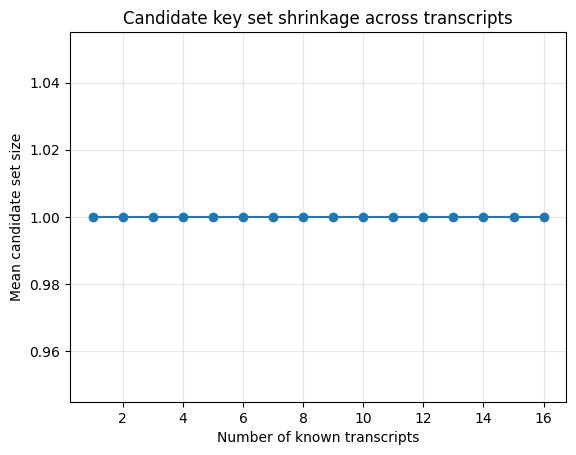

In [9]:
started = time.perf_counter()

def rank_vectors_of_length(length_n, max_count):
    rows = []
    for payload in payload_records:
        ids = payload["token_ids"]
        if len(ids) == length_n:
            aligned_ids = ids
            source = "exact_length"
        elif len(ids) > length_n:
            aligned_ids = ids[:length_n]
            source = "truncated_to_required_length"
        else:
            continue
        trace = cu.rank_trace_from_token_ids(llm, cu._make_prefix_ids(CONFIG["secret_prefix"], llm), aligned_ids)
        rows.append({"payload_id": payload["payload_id"], "payload_text": payload["text"], "source": source, "token_ids": aligned_ids, "ranks": trace["ranks"]})
    return rows[:max_count]

exp4_rows = []
limited_collision_pairs = collision_pairs[: min(len(collision_pairs), 20)]
if limited_collision_pairs:
    for pair_id, pair in enumerate(limited_collision_pairs):
        new_vectors = rank_vectors_of_length(pair["rank_length"], CONFIG["num_stability_payloads"])
        exact_hits = 0
        for rv in new_vectors:
            u = cu.F_key_on_ranks(rv["ranks"], pair["key_a"], llm, CONFIG["secret_prefix"], use_cache=True)
            v = cu.F_key_on_ranks(rv["ranks"], pair["key_b"], llm, CONFIG["secret_prefix"], use_cache=True)
            exact = (u == v)
            exact_hits += int(exact)
            exp4_rows.append({
                "pair_id": pair_id,
                "pair_type": "discovered_collision_pair",
                "key_a": pair["key_a"],
                "key_b": pair["key_b"],
                "payload_id": rv["payload_id"],
                "payload_alignment": rv["source"],
                "rank_length": pair["rank_length"],
                "exact_equal": exact,
                "rank_hamming_distance": cu.normalized_rank_hamming(u, v),
                "log_rank_distance": cu.normalized_log_rank_distance(u, v, VOCAB_SIZE or 128000),
                "token_edit_after_G_empty": cu.token_edit_distance(cu.generate_token_ids_from_ranks(llm, cu._make_prefix_ids(CONFIG["secret_prefix"], llm), u)["generated_ids"], cu.generate_token_ids_from_ranks(llm, cu._make_prefix_ids(CONFIG["secret_prefix"], llm), v)["generated_ids"]),
            })
        ci = cu.wilson_interval(exact_hits, max(len(new_vectors), 1))
        for row in exp4_rows:
            if row["pair_id"] == pair_id:
                row["exact_stability_rate_for_pair"] = exact_hits / max(len(new_vectors), 1)
                row["exact_stability_wilson95_low"] = ci[0]
                row["exact_stability_wilson95_high"] = ci[1]

shrinkage_rows = []
for true_key_index, true_key in enumerate(K_ADM[:CONFIG["num_shrinkage_true_keys"]]):
    candidates = set(K_ADM)
    for t, payload in enumerate(payload_records[:CONFIG["num_stability_payloads"]], start=1):
        ranks = cu.rank_trace_from_token_ids(llm, cu._make_prefix_ids(CONFIG["secret_prefix"], llm), payload["token_ids"])["ranks"]
        target = cu.F_key_on_ranks(ranks, true_key, llm, CONFIG["secret_prefix"], use_cache=True)
        candidates = {candidate_key for candidate_key in candidates if cu.F_key_on_ranks(ranks, candidate_key, llm, CONFIG["secret_prefix"], use_cache=True) == target}
        shrinkage_rows.append({
            "true_key_index": true_key_index,
            "true_key": true_key,
            "num_transcripts": t,
            "candidate_set_size": len(candidates),
            "true_key_still_present": true_key in candidates,
        })

cu.write_csv(cu.TABLES_DIR / "experiment4_collision_stability.csv", exp4_rows)
cu.write_csv(cu.TABLES_DIR / "experiment4_candidate_shrinkage.csv", shrinkage_rows)
cu.write_json(cu.RAW_DIR / "experiment4_collision_stability.json", {"stability_rows": exp4_rows, "shrinkage_rows": shrinkage_rows})
record_table("experiment4_collision_stability.csv", "Experiment 4", "Collision stability across new payload rank vectors; empty if no collisions were found.", "Multi-payload collision stability under finite K_adm.")
record_table("experiment4_candidate_shrinkage.csv", "Experiment 4", "Candidate set size after accumulating transcripts.", "Multi-transcript ambiguity under finite K_adm.")

if exp4_rows:
    stability_rates = [row["exact_stability_rate_for_pair"] for row in exp4_rows if "exact_stability_rate_for_pair" in row]
    cu.histogram(stability_rates, "exp4_stability_rate_histogram.png", "Collision stability across new payloads", "Exact stability rate", bins=10)
    record_figure("exp4_stability_rate_histogram.png", "Experiment 4", "Exact stability rates for discovered collision pairs.", "Local versus stable collisions.")
    distances_by_type = defaultdict(list)
    for row in exp4_rows:
        distances_by_type[row["pair_type"]].append(row["rank_hamming_distance"])
    cu.boxplot(distances_by_type, "exp4_rank_distance_boxplot.png", "Output divergence for colliding key pairs", "Normalized rank Hamming distance")
    record_figure("exp4_rank_distance_boxplot.png", "Experiment 4", "Output divergence for discovered collision pairs.", "Collision stability divergence.")

# Average shrinkage curve across selected true keys.
by_t = defaultdict(list)
for row in shrinkage_rows:
    by_t[row["num_transcripts"]].append(row["candidate_set_size"])
xs = sorted(by_t)
ys = [statistics.mean(by_t[t]) for t in xs]
cu.line_plot(xs, ys, "exp4_candidate_set_size_vs_transcripts.png", "Candidate key set shrinkage across transcripts", "Number of known transcripts", "Mean candidate set size")
record_figure("exp4_candidate_set_size_vs_transcripts.png", "Experiment 4", "Mean finite candidate key set size after accumulating transcripts.", "Multi-transcript candidate shrinkage.")

final_candidate_mean = ys[-1] if ys else float("nan")
if exp4_rows:
    summary = f"Collision stability ran on {len(limited_collision_pairs)} discovered collision pairs. Mean final candidate set size after {len(xs)} transcripts was {final_candidate_mean:.3f}."
else:
    summary = f"Collision stability skipped because no collisions were found. Candidate shrinkage still ran; mean candidate set size after {len(xs)} transcripts was {final_candidate_mean:.3f}."
PAPER_BULLETS.append(summary)
RUN_NUMERIC_RESULTS.update({"candidate_shrinkage_final_mean": final_candidate_mean})
cu.append_summary("Collision stability and candidate shrinkage result", summary)
mark_experiment("experiment4_collision_stability", "run", started, "collision stability skipped" if not exp4_rows else "")
show_rows(exp4_rows)
show_rows(shrinkage_rows)


# Experiment 5: Non-commutativity of key-induced maps

For sampled key pairs `(k,h)` and payload rank vectors `r`, this compares `F_k(F_h(r))` with `F_h(F_k(r))`. Exact equality is sample-level equality only; failure to find commuting pairs is not an impossibility result.


experiment5_noncommutativity: run in 2265.8s 


[{'pair_id': 0,
  'key_k': 'Write a neutral product description in one paragraph.',
  'key_h': 'The quick brown fox',
  'sampled_commutation_successes': 0,
  'num_payloads': 8,
  'sampled_commutation_rate': 0.0,
  'sampled_commutation_wilson95_low': 0.0,
  'sampled_commutation_wilson95_high': 0.32440756488388023,
  'mean_log_rank_commutation_distance': 0.15241733672455718,
  'p05_log_rank_commutation_distance': 0.07725787662903418,
  'p50_log_rank_commutation_distance': 0.14273704826831723,
  'p95_log_rank_commutation_distance': 0.2547586237051232},
 {'pair_id': 1,
  'key_k': 'Talk about animals in a forest.',
  'key_h': 'xrite a neutral product description.',
  'sampled_commutation_successes': 0,
  'num_payloads': 8,
  'sampled_commutation_rate': 0.0,
  'sampled_commutation_wilson95_low': 0.0,
  'sampled_commutation_wilson95_high': 0.32440756488388023,
  'mean_log_rank_commutation_distance': 0.1481159919346005,
  'p05_log_rank_commutation_distance': 0.0866804817190432,
  'p50_log_rank

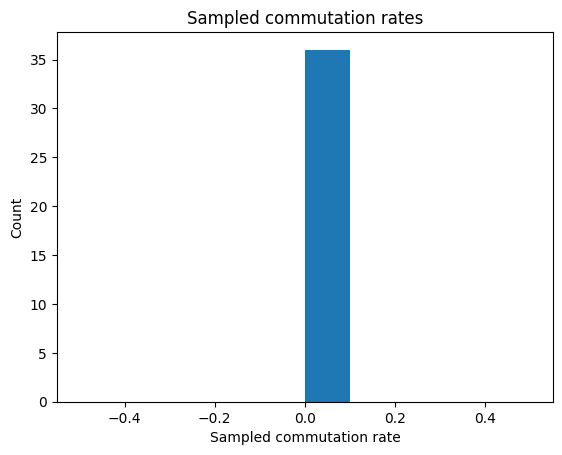

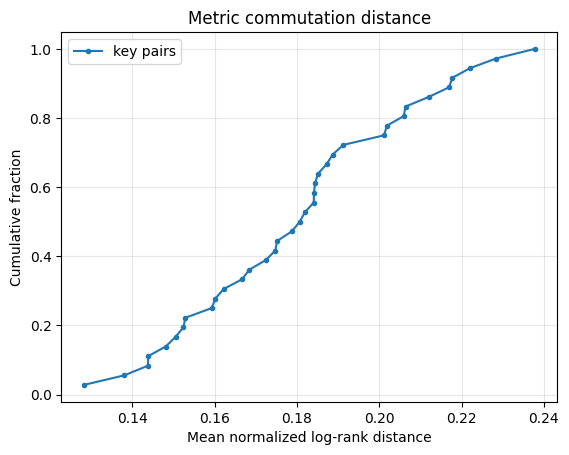

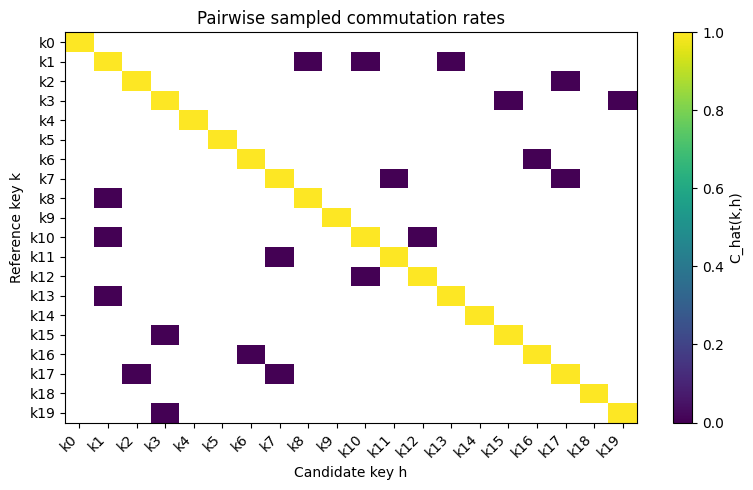

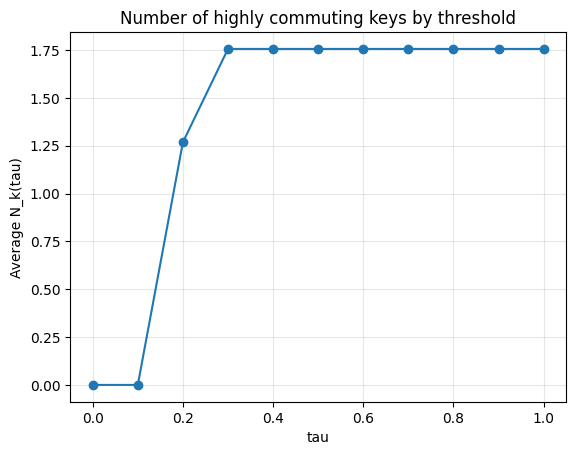

In [10]:
remaining_before_exp5 = CONFIG["max_runtime_seconds"] - elapsed_run_seconds()
estimated_exp5 = CONFIG.get("estimated_runtime_components_seconds_from_previous", {}).get("experiment5_noncommutativity")
estimated_exp6 = CONFIG.get("estimated_runtime_components_seconds_from_previous", {}).get("experiment6_robustness")
if estimated_exp5 and estimated_exp6 and remaining_before_exp5 < (estimated_exp5 + estimated_exp6):
    old_pairs = CONFIG["num_commutativity_pairs"]
    per_pair = estimated_exp5 / max(old_pairs, 1)
    reserve_for_robustness = min(estimated_exp6, max(0.0, remaining_before_exp5 * 0.35))
    allowed_pairs = int(max(4, (remaining_before_exp5 - reserve_for_robustness) / max(per_pair, 1e-9)))
    if allowed_pairs < old_pairs:
        CONFIG["num_commutativity_pairs"] = max(4, allowed_pairs)
        BUDGET_ADJUSTMENTS.append({"field": "num_commutativity_pairs", "old_value": old_pairs, "new_value": CONFIG["num_commutativity_pairs"], "reason": "late time-budget check before Experiment 5"})
        print("Reduced num_commutativity_pairs for time budget:", old_pairs, "->", CONFIG["num_commutativity_pairs"])

started = time.perf_counter()
all_key_pairs = list(itertools.combinations(K_ADM, 2))
rng = random.Random(CONFIG["random_seed"] + 5)
rng.shuffle(all_key_pairs)
sampled_key_pairs_5 = all_key_pairs[:CONFIG["num_commutativity_pairs"]]
rank_vectors_5 = []
for payload in payload_records[:CONFIG["num_commutativity_payloads"]]:
    trace = cu.rank_trace_from_token_ids(llm, cu._make_prefix_ids(CONFIG["secret_prefix"], llm), payload["token_ids"])
    rank_vectors_5.append({"payload_id": payload["payload_id"], "payload_text": payload["text"], "ranks": trace["ranks"]})

pair_summary_5 = []
exp5_raw_rows = []
for pair_id, (k, h) in enumerate(sampled_key_pairs_5):
    exact_count = 0
    distances = []
    for rv in rank_vectors_5:
        fh = cu.F_key_on_ranks(rv["ranks"], h, llm, CONFIG["secret_prefix"], use_cache=True)
        fk = cu.F_key_on_ranks(rv["ranks"], k, llm, CONFIG["secret_prefix"], use_cache=True)
        fk_fh = cu.F_key_on_ranks(fh, k, llm, CONFIG["secret_prefix"], use_cache=True)
        fh_fk = cu.F_key_on_ranks(fk, h, llm, CONFIG["secret_prefix"], use_cache=True)
        exact = fk_fh == fh_fk
        distance = cu.normalized_log_rank_distance(fk_fh, fh_fk, VOCAB_SIZE or 128000)
        exact_count += int(exact)
        distances.append(distance)
        exp5_raw_rows.append({"pair_id": pair_id, "payload_id": rv["payload_id"], "exact_commutes_on_payload": exact, "log_rank_commutation_distance": distance})
    ci = cu.wilson_interval(exact_count, len(rank_vectors_5))
    pair_summary_5.append({
        "pair_id": pair_id,
        "key_k": k,
        "key_h": h,
        "sampled_commutation_successes": exact_count,
        "num_payloads": len(rank_vectors_5),
        "sampled_commutation_rate": exact_count / max(len(rank_vectors_5), 1),
        "sampled_commutation_wilson95_low": ci[0],
        "sampled_commutation_wilson95_high": ci[1],
        "mean_log_rank_commutation_distance": statistics.mean(distances) if distances else float("nan"),
        "p05_log_rank_commutation_distance": float(np.quantile(distances, 0.05)) if distances else float("nan"),
        "p50_log_rank_commutation_distance": float(np.quantile(distances, 0.50)) if distances else float("nan"),
        "p95_log_rank_commutation_distance": float(np.quantile(distances, 0.95)) if distances else float("nan"),
    })

cu.write_csv(cu.TABLES_DIR / "experiment5_noncommutativity.csv", pair_summary_5)
cu.write_json(cu.RAW_DIR / "experiment5_noncommutativity.json", {"pair_summary": pair_summary_5, "payload_rows": exp5_raw_rows})
record_table("experiment5_noncommutativity.csv", "Experiment 5", "Sampled commutation rates and log-rank distances for key-induced maps.", "Non-commutativity of F_k maps.")

cu.histogram([row["sampled_commutation_rate"] for row in pair_summary_5], "exp5_commutation_rate_histogram.png", "Sampled commutation rates", "Sampled commutation rate", bins=10)
record_figure("exp5_commutation_rate_histogram.png", "Experiment 5", "Histogram of sampled exact commutation rates.", "Non-commutativity in tested key pairs.")
cu.empirical_cdf({"key pairs": [row["mean_log_rank_commutation_distance"] for row in pair_summary_5]}, "exp5_commutation_distance_cdf.png", "Metric commutation distance", "Mean normalized log-rank distance")
record_figure("exp5_commutation_distance_cdf.png", "Experiment 5", "Empirical CDF of mean metric commutation distances.", "Metric non-commutativity in tested key pairs.")

heat_keys = list(dict.fromkeys([row["key_k"] for row in pair_summary_5] + [row["key_h"] for row in pair_summary_5]))[:20]
index = {key: idx for idx, key in enumerate(heat_keys)}
heat = np.full((len(heat_keys), len(heat_keys)), np.nan)
for row in pair_summary_5:
    if row["key_k"] in index and row["key_h"] in index:
        i = index[row["key_k"]]
        j = index[row["key_h"]]
        heat[i, j] = row["sampled_commutation_rate"]
        heat[j, i] = row["sampled_commutation_rate"]
np.fill_diagonal(heat, 1.0)
cu.heatmap(heat, "exp5_commutation_heatmap.png", "Pairwise sampled commutation rates", "Candidate key h", "Reference key k", xticklabels=[f"k{i}" for i in range(len(heat_keys))], yticklabels=[f"k{i}" for i in range(len(heat_keys))], colorbar_label="C_hat(k,h)", vmin=0.0, vmax=1.0)
record_figure("exp5_commutation_heatmap.png", "Experiment 5", "Heatmap of sampled commutation rates among displayed keys.", "Pairwise non-commutativity structure.")

taus = np.linspace(0.0, 1.0, 11)
threshold_rows = []
for tau in taus:
    counts_by_k = defaultdict(int)
    seen_by_k = defaultdict(int)
    for row in pair_summary_5:
        for key in [row["key_k"], row["key_h"]]:
            seen_by_k[key] += 1
            if row["mean_log_rank_commutation_distance"] <= tau:
                counts_by_k[key] += 1
    threshold_rows.append({"tau": float(tau), "average_N_k_tau": statistics.mean(counts_by_k[key] for key in seen_by_k) if seen_by_k else 0.0})
cu.write_csv(cu.TABLES_DIR / "experiment5_Nk_tau_curve.csv", threshold_rows)
record_table("experiment5_Nk_tau_curve.csv", "Experiment 5", "Average number of highly commuting keys by metric threshold.", "Related-instance commutation structure.")
cu.line_plot([row["tau"] for row in threshold_rows], [row["average_N_k_tau"] for row in threshold_rows], "exp5_Nk_tau_curve.png", "Number of highly commuting keys by threshold", "tau", "Average N_k(tau)")
record_figure("exp5_Nk_tau_curve.png", "Experiment 5", "Average number of key partners below a commutation-distance threshold.", "Related-instance threshold behavior.")

exact_pairs = sum(1 for row in pair_summary_5 if row["sampled_commutation_rate"] == 1.0)
distances = [row["mean_log_rank_commutation_distance"] for row in pair_summary_5]
median_distance = statistics.median(distances) if distances else float("nan")
p05, p50, p95 = (float(np.quantile(distances, q)) if distances else float("nan") for q in [0.05, 0.5, 0.95])
summary = (
    f"Exact sampled commuting pairs observed: {exact_pairs}/{len(pair_summary_5)}. "
    f"Median D_log was {median_distance:.4f}; 5th/50th/95th percentiles were {p05:.4f}/{p50:.4f}/{p95:.4f}. "
    "No impossibility claim is made if no exact commuting pairs were found."
)
PAPER_BULLETS.append(summary)
RUN_NUMERIC_RESULTS.update({"exact_commuting_pairs": exact_pairs, "commuting_pair_total": len(pair_summary_5), "median_commutation_distance": median_distance})
cu.append_summary("Non-commutativity result", summary)
mark_experiment("experiment5_noncommutativity", "run", started)
show_rows(pair_summary_5)


# Experiment 6: Robustness to token perturbations

Base CARTS is exact only when the stegotext token sequence is unchanged. This experiment applies length-preserving perturbations and measures decoded errors.


experiment6_robustness: run in 561.9s 


[{'case_id': 0,
  'payload_id': 11,
  'key_id': 26,
  'payload_text': 'Several people waited near the market.',
  'key_text': 'Talk about animals in a forest in one paragraph.',
  'perturbation_type': 'random_token_substitution',
  'perturbation_position': 3,
  'token_length': 7,
  'decoded_token_edit_distance': 4,
  'normalized_decoded_token_edit_distance': 0.5714285714285714,
  'first_mismatch_position': 3,
  'suffix_corruption_fraction': 1.0,
  'corrupted': True,
  'original_stegotext': ' browse this timeline from the chimpanpan',
  'perturbed_stegotext': ' browse this timeline Custom the chimpanpan',
  'decoded_original': ' Several people waited near the market.',
  'decoded_perturbed': ' Several people waited appearing wearing myriad attire',
  'corruption_rate': 1.0,
  'corruption_wilson95_low': 0.9541818704644728,
  'corruption_wilson95_high': 0.9999999999999999},
 {'case_id': 0,
  'payload_id': 11,
  'key_id': 26,
  'payload_text': 'Several people waited near the market.',
  'k

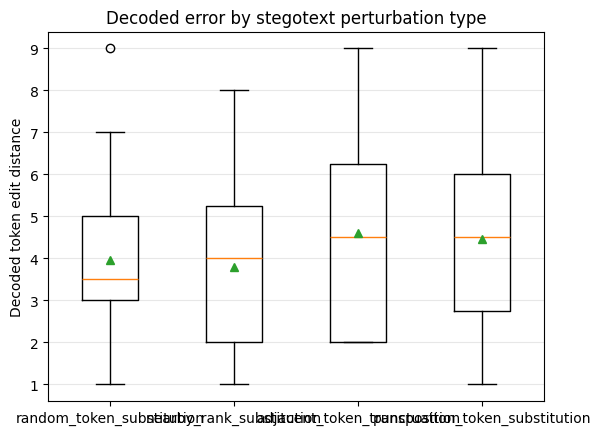

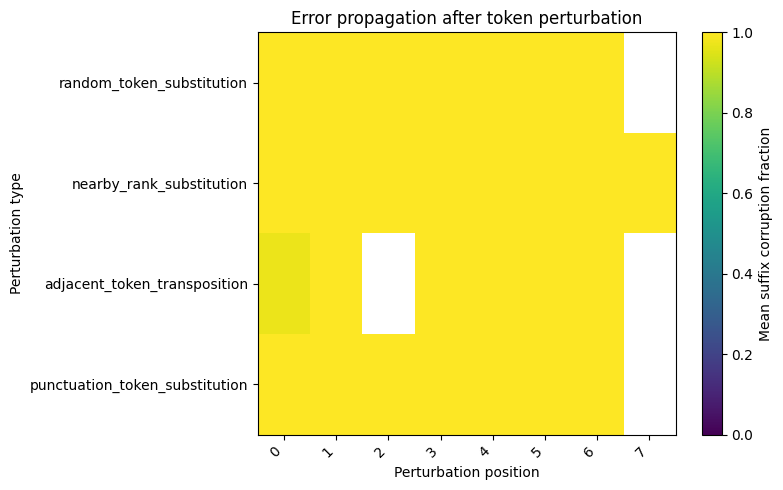

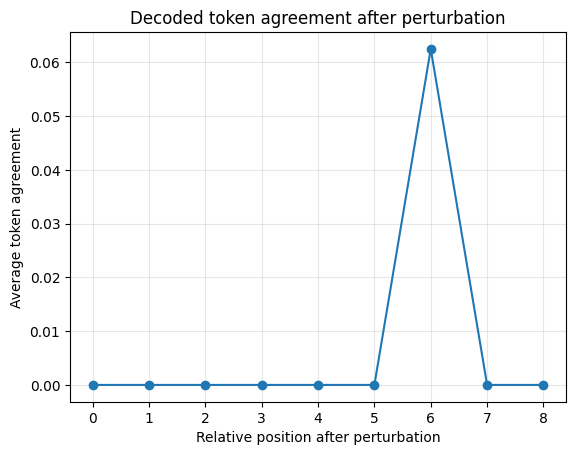

In [11]:
remaining_before_exp6 = CONFIG["max_runtime_seconds"] - elapsed_run_seconds()
estimated_exp6 = CONFIG.get("estimated_runtime_components_seconds_from_previous", {}).get("experiment6_robustness")
if estimated_exp6 and remaining_before_exp6 < estimated_exp6:
    old_cases = CONFIG["num_robustness_cases"]
    per_case = estimated_exp6 / max(old_cases, 1)
    allowed_cases = int(max(4, remaining_before_exp6 / max(per_case, 1e-9)))
    if allowed_cases < old_cases:
        CONFIG["num_robustness_cases"] = max(4, allowed_cases)
        BUDGET_ADJUSTMENTS.append({"field": "num_robustness_cases", "old_value": old_cases, "new_value": CONFIG["num_robustness_cases"], "reason": "late time-budget check before Experiment 6"})
        print("Reduced num_robustness_cases for time budget:", old_cases, "->", CONFIG["num_robustness_cases"])

started = time.perf_counter()

def token_at_rank_after_prefix(key_text, prefix_ids, rank):
    llm.reset()
    llm.eval(cu._make_prefix_ids(key_text, llm))
    for token_id in prefix_ids:
        llm.eval([int(token_id)])
    logits = np.asarray(llm.scores[llm.n_tokens - 1], dtype=np.float64)
    return cu.token_at_rank(logits, int(rank))

punctuation_token_ids = []
for mark in [".", ",", ";", ":", "!", "?", " -", " _"]:
    ids = cu.text_to_payload_ids(mark, llm)
    if len(ids) == 1:
        punctuation_token_ids.append(ids[0])
punctuation_token_ids = list(dict.fromkeys(punctuation_token_ids))


def perturb_stegotext(stego_ids, key_text, stego_ranks, perturbation_type, seed):
    rng = random.Random(seed)
    ids = list(map(int, stego_ids))
    if not ids:
        return ids, None, "empty_sequence"
    position = rng.randrange(len(ids))
    if perturbation_type == "random_token_substitution":
        vocab = VOCAB_SIZE or 128000
        replacement = (ids[position] + 7919 + seed) % vocab
        if replacement == ids[position]:
            replacement = (replacement + 1) % vocab
        ids[position] = int(replacement)
    elif perturbation_type == "nearby_rank_substitution":
        current_rank = int(stego_ranks[position])
        near_rank = current_rank + 1 if (VOCAB_SIZE is None or current_rank < VOCAB_SIZE) else max(1, current_rank - 1)
        replacement = token_at_rank_after_prefix(key_text, ids[:position], near_rank)
        if replacement == ids[position] and near_rank > 1:
            replacement = token_at_rank_after_prefix(key_text, ids[:position], near_rank - 1)
        ids[position] = int(replacement)
    elif perturbation_type == "adjacent_token_transposition":
        if len(ids) < 2:
            return ids, position, "too_short_for_transposition"
        if position == len(ids) - 1:
            position -= 1
        ids[position], ids[position + 1] = ids[position + 1], ids[position]
    elif perturbation_type == "punctuation_token_substitution":
        if not punctuation_token_ids:
            return ids, position, "no_punctuation_token"
        replacement = punctuation_token_ids[seed % len(punctuation_token_ids)]
        if replacement == ids[position] and len(punctuation_token_ids) > 1:
            replacement = punctuation_token_ids[(seed + 1) % len(punctuation_token_ids)]
        ids[position] = int(replacement)
    else:
        raise ValueError(f"Unknown perturbation type: {perturbation_type}")
    return ids, position, "ok"

perturbation_types = ["random_token_substitution", "nearby_rank_substitution", "adjacent_token_transposition", "punctuation_token_substitution"]
exp6_rows = []
agreement_by_type_offset = defaultdict(list)
heat_accumulator = defaultdict(list)

for case_id, (payload, key) in enumerate(sampled_payload_key_pairs(CONFIG["num_robustness_cases"])):
    encoded = cu.E_key_token_ids(llm, payload["token_ids"], key["text"], CONFIG["secret_prefix"])
    decoded_original = cu.D_key_token_ids(llm, encoded["stegotext_ids"], key["text"], CONFIG["secret_prefix"])
    if not cu.exact_match(decoded_original["decoded_ids"], payload["token_ids"]):
        continue
    stego_trace = cu.rank_trace_from_token_ids(llm, cu._make_prefix_ids(key["text"], llm), encoded["stegotext_ids"])
    for ptype in perturbation_types:
        perturbed_ids, position, status = perturb_stegotext(encoded["stegotext_ids"], key["text"], stego_trace["ranks"], ptype, CONFIG["random_seed"] + case_id * 100 + len(ptype))
        if status != "ok":
            continue
        decoded_perturbed = cu.D_key_token_ids(llm, perturbed_ids, key["text"], CONFIG["secret_prefix"])
        edit = cu.token_edit_distance(payload["token_ids"], decoded_perturbed["decoded_ids"])
        norm_edit = cu.normalized_token_edit_distance(payload["token_ids"], decoded_perturbed["decoded_ids"])
        mismatch = cu.first_mismatch_position(payload["token_ids"], decoded_perturbed["decoded_ids"])
        suffix_fraction = cu.suffix_corruption_fraction(payload["token_ids"], decoded_perturbed["decoded_ids"])
        corrupted = not cu.exact_match(payload["token_ids"], decoded_perturbed["decoded_ids"])
        row = {
            "case_id": case_id,
            "payload_id": payload["payload_id"],
            "key_id": key["key_id"],
            "payload_text": payload["text"],
            "key_text": key["text"],
            "perturbation_type": ptype,
            "perturbation_position": position,
            "token_length": len(payload["token_ids"]),
            "decoded_token_edit_distance": edit,
            "normalized_decoded_token_edit_distance": norm_edit,
            "first_mismatch_position": mismatch,
            "suffix_corruption_fraction": suffix_fraction,
            "corrupted": corrupted,
            "original_stegotext": encoded["stegotext_text"],
            "perturbed_stegotext": cu.safe_detokenize(perturbed_ids, llm),
            "decoded_original": decoded_original["decoded_text"],
            "decoded_perturbed": decoded_perturbed["decoded_text"],
        }
        exp6_rows.append(row)
        heat_accumulator[(ptype, position)].append(suffix_fraction)
        for offset in range(max(0, len(payload["token_ids"]) - position)):
            idx = position + offset
            agreement = int(idx < len(decoded_perturbed["decoded_ids"]) and payload["token_ids"][idx] == decoded_perturbed["decoded_ids"][idx])
            agreement_by_type_offset[(ptype, offset)].append(agreement)

corruption_count = sum(row["corrupted"] for row in exp6_rows)
corruption_ci = cu.wilson_interval(corruption_count, len(exp6_rows))
for row in exp6_rows:
    row.update({
        "corruption_rate": corruption_count / max(len(exp6_rows), 1),
        "corruption_wilson95_low": corruption_ci[0],
        "corruption_wilson95_high": corruption_ci[1],
    })

cu.write_csv(cu.TABLES_DIR / "experiment6_robustness.csv", exp6_rows)
cu.write_json(cu.RAW_DIR / "experiment6_robustness.json", exp6_rows)
record_table("experiment6_robustness.csv", "Experiment 6", "Decoded errors after length-preserving stegotext token perturbations.", "Perturbation brittleness of base CARTS.")

if exp6_rows:
    edit_by_type = defaultdict(list)
    suffix_by_type = defaultdict(list)
    for row in exp6_rows:
        edit_by_type[row["perturbation_type"]].append(row["decoded_token_edit_distance"])
        suffix_by_type[row["perturbation_type"]].append(row["suffix_corruption_fraction"])
    perturbation_label_map = {
        "random_token_substitution": "Random token substitution",
        "nearby_rank_substitution": "Nearby-rank substitution",
        "adjacent_token_transposition": "Adjacent token transposition",
        "punctuation_token_substitution": "Punctuation-token substitution",
    }
    perturbation_order = [
        "random_token_substitution",
        "nearby_rank_substitution",
        "adjacent_token_transposition",
        "punctuation_token_substitution",
    ]
    cu.horizontal_boxplot(
        edit_by_type,
        "exp6_decoded_edit_distance_by_perturbation.png",
        "Decoded error by stegotext perturbation type",
        "Decoded token edit distance",
        "Perturbation type",
        label_map=perturbation_label_map,
        order=perturbation_order,
        pdf_filename="exp6_decoded_edit_distance_by_perturbation.pdf",
        alternate_png_filename="exp6_decoded_edit_distance_by_perturbation_horizontal.png",
    )
    record_figure("exp6_decoded_edit_distance_by_perturbation.png", "Experiment 6", "Horizontal boxplot of decoded token edit distance by length-preserving perturbation type.", "Perturbation brittleness.")
    max_position = max(row["perturbation_position"] for row in exp6_rows)
    heat = np.full((len(perturbation_types), max_position + 1), np.nan)
    for i, ptype in enumerate(perturbation_types):
        for pos in range(max_position + 1):
            values = heat_accumulator.get((ptype, pos), [])
            if values:
                heat[i, pos] = statistics.mean(values)
    cu.heatmap(heat, "exp6_perturb_position_vs_error_heatmap.png", "Error propagation after token perturbation", "Perturbation position", "Perturbation type", xticklabels=[str(i) for i in range(max_position + 1)], yticklabels=perturbation_types, colorbar_label="Mean suffix corruption fraction", vmin=0.0, vmax=1.0)
    record_figure("exp6_perturb_position_vs_error_heatmap.png", "Experiment 6", "Mean suffix corruption fraction by perturbation type and position.", "Error propagation after perturbation.")
    max_offset = max(offset for (_, offset) in agreement_by_type_offset.keys()) if agreement_by_type_offset else 0
    offsets = list(range(max_offset + 1))
    agreement_values = []
    for offset in offsets:
        values = []
        for ptype in perturbation_types:
            values.extend(agreement_by_type_offset.get((ptype, offset), []))
        agreement_values.append(statistics.mean(values) if values else float("nan"))
    cu.line_plot(offsets, agreement_values, "exp6_token_agreement_after_perturbation.png", "Decoded token agreement after perturbation", "Relative position after perturbation", "Average token agreement")
    record_figure("exp6_token_agreement_after_perturbation.png", "Experiment 6", "Average decoded token agreement after the perturbation position.", "Error propagation after perturbation.")

avg_edit_by_type = {ptype: statistics.mean(vals) for ptype, vals in edit_by_type.items()} if exp6_rows else {}
avg_suffix_by_type = {ptype: statistics.mean(vals) for ptype, vals in suffix_by_type.items()} if exp6_rows else {}
avg_edit = statistics.mean([row["decoded_token_edit_distance"] for row in exp6_rows]) if exp6_rows else float("nan")
summary = (
    f"A single length-preserving token perturbation caused average decoded edit distance {avg_edit:.4f} over {len(exp6_rows)} tested perturbations. "
    f"The corruption rate was {corruption_count}/{len(exp6_rows)} (Wilson 95% CI [{corruption_ci[0]:.3f}, {corruption_ci[1]:.3f}]). "
    f"Average decoded edit distance by perturbation type: {avg_edit_by_type}. Average suffix corruption by type: {avg_suffix_by_type}. "
    "Base CARTS is exact but not robust to unmodified-stegotext assumptions under these perturbation types."
)
PAPER_BULLETS.append(summary)
RUN_NUMERIC_RESULTS.update({"robustness_average_decoded_edit_distance": avg_edit, "robustness_corruption_count": corruption_count, "robustness_total": len(exp6_rows)})
CONFIG["num_robustness_perturbations"] = len(exp6_rows)
cu.append_summary("Robustness result", summary)
mark_experiment("experiment6_robustness", "run", started)
show_rows(exp6_rows)


# Optional and future experiments

These hooks are intentionally off by default. They are included for future paper extensions without changing the core six-experiment protocol.

- Key-length cardinality toy regimes: reduced finite demonstration only, not a Llama-scale security estimate.
- Key sensitivity and avalanche-style behavior: small prompt edits versus output rank distance.
- Wrong-key decoding and restricted equivocation: requires an explicit plausibility metric and calibration protocol.
- Advanced context-search baselines: separate exact candidate sets from heuristic rankings.


In [12]:
RUN_OPTIONAL_TOY_CARDINALITY = False
RUN_OPTIONAL_KEY_SENSITIVITY = False
RUN_OPTIONAL_WRONG_KEY_EQUIVOCATION = False
RUN_OPTIONAL_CONTEXT_SEARCH_BASELINES = False

if RUN_OPTIONAL_TOY_CARDINALITY:
    print("Toy cardinality experiment hook. Keep n and key alphabet very small.")
if RUN_OPTIONAL_KEY_SENSITIVITY:
    print("Key sensitivity experiment hook. Reuse F_key_on_ranks and rank distances.")
if RUN_OPTIONAL_WRONG_KEY_EQUIVOCATION:
    print("Wrong-key equivocation requires a calibrated plausibility metric.")
if RUN_OPTIONAL_CONTEXT_SEARCH_BASELINES:
    print("Context-search baselines should be reported separately from exact candidate sets.")


# Paper verification checklist and final outputs

This section regenerates manifests, the paper verification checklist, the run manifest, and the final paper-ready bullets. All paths are relative to `paper-empirical-explorations/`.


CSV files:
 - results/tables/experiment1_correctness.csv
 - results/tables/experiment2_detector_auc.csv
 - results/tables/experiment2_rank_likelihood_detection.csv
 - results/tables/experiment3_key_collision_fibers.csv
 - results/tables/experiment3_largest_fibers.csv
 - results/tables/experiment3_search_cost.csv
 - results/tables/experiment4_candidate_shrinkage.csv
 - results/tables/experiment4_collision_stability.csv
 - results/tables/experiment5_Nk_tau_curve.csv
 - results/tables/experiment5_noncommutativity.csv
 - results/tables/experiment6_robustness.csv
 - results/tables/figure_manifest.csv
 - results/tables/keys.csv
 - results/tables/paper_verification_checklist.csv
 - results/tables/payloads.csv
 - results/tables/table_manifest.csv
Markdown summary: results/text/empirical_summary.md
Paper-ready result bullets:
- Exact recovery succeeded in 40/40 payload-key pairs (rate 1.000, Wilson 95% CI [0.912, 1.000]). Reverse-direction recovery succeeded in 40/40 cases (rate 1.000, Wilson 9

[{'Theory claim': 'Exact invertibility',
  'Experiment supporting it': 'Experiment 1',
  'Figure/table produced': 'experiment1_correctness.csv, exp1_correctness_bar.png',
  'Status': 'pass',
  'Caveat': 'Sample-level implementation verification; theorem is mathematical.'},
 {'Theory claim': 'Rank pressure and quality',
  'Experiment supporting it': 'Experiment 2',
  'Figure/table produced': 'exp2_nll_boxplot.png, exp2_mean_log_rank_cdf.png',
  'Status': 'reported',
  'Caveat': 'Depends on Q_k.'},
 {'Theory claim': 'Simple detectability',
  'Experiment supporting it': 'Experiment 2',
  'Figure/table produced': 'exp2_detector_roc.png',
  'Status': 'reported',
  'Caveat': 'Distribution-specific, not a proof of security/insecurity.'},
 {'Theory claim': 'Key-collision fibers',
  'Experiment supporting it': 'Experiment 3',
  'Figure/table produced': 'exp3_fiber_size_histogram.png, experiment3_largest_fibers.csv',
  'Status': 'reported',
  'Caveat': 'Finite K_adm only.'},
 {'Theory claim': 'M

### exp1_correctness_bar.png

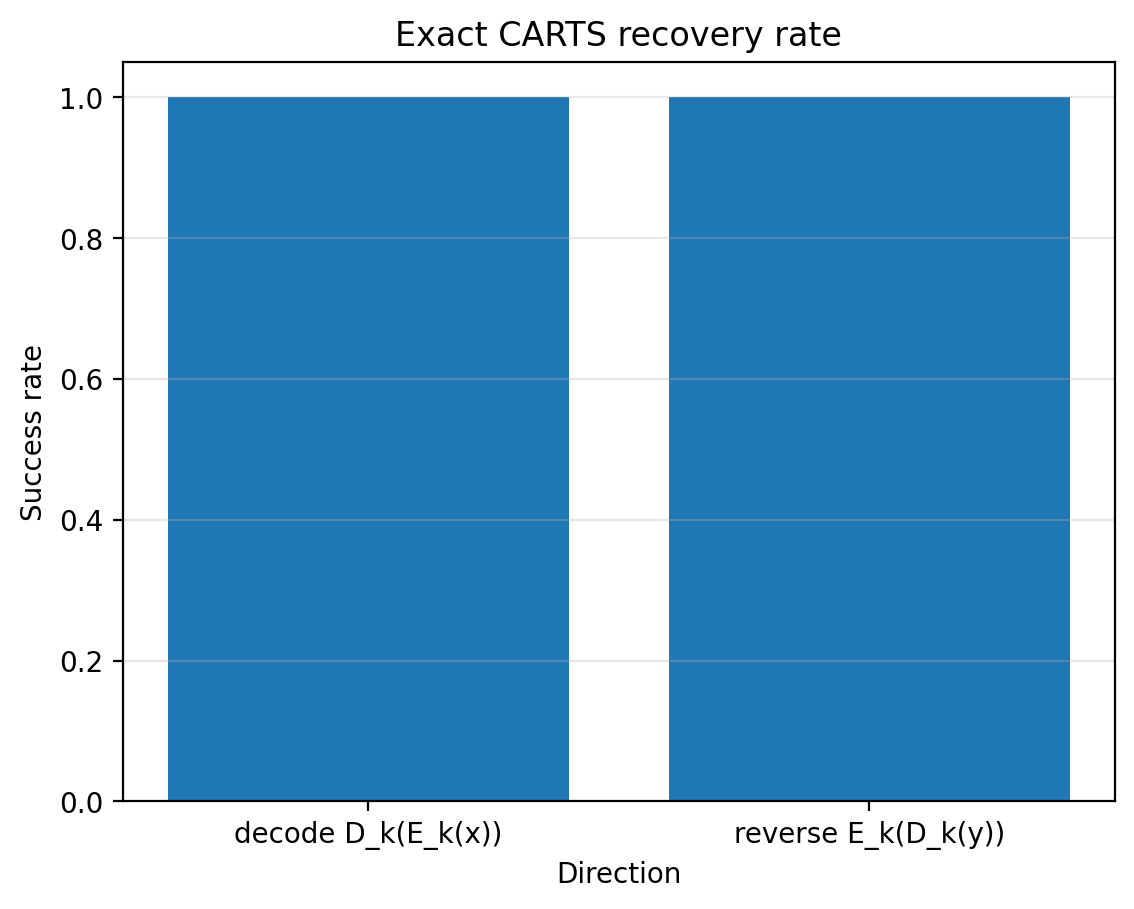

### exp2_detector_roc.png

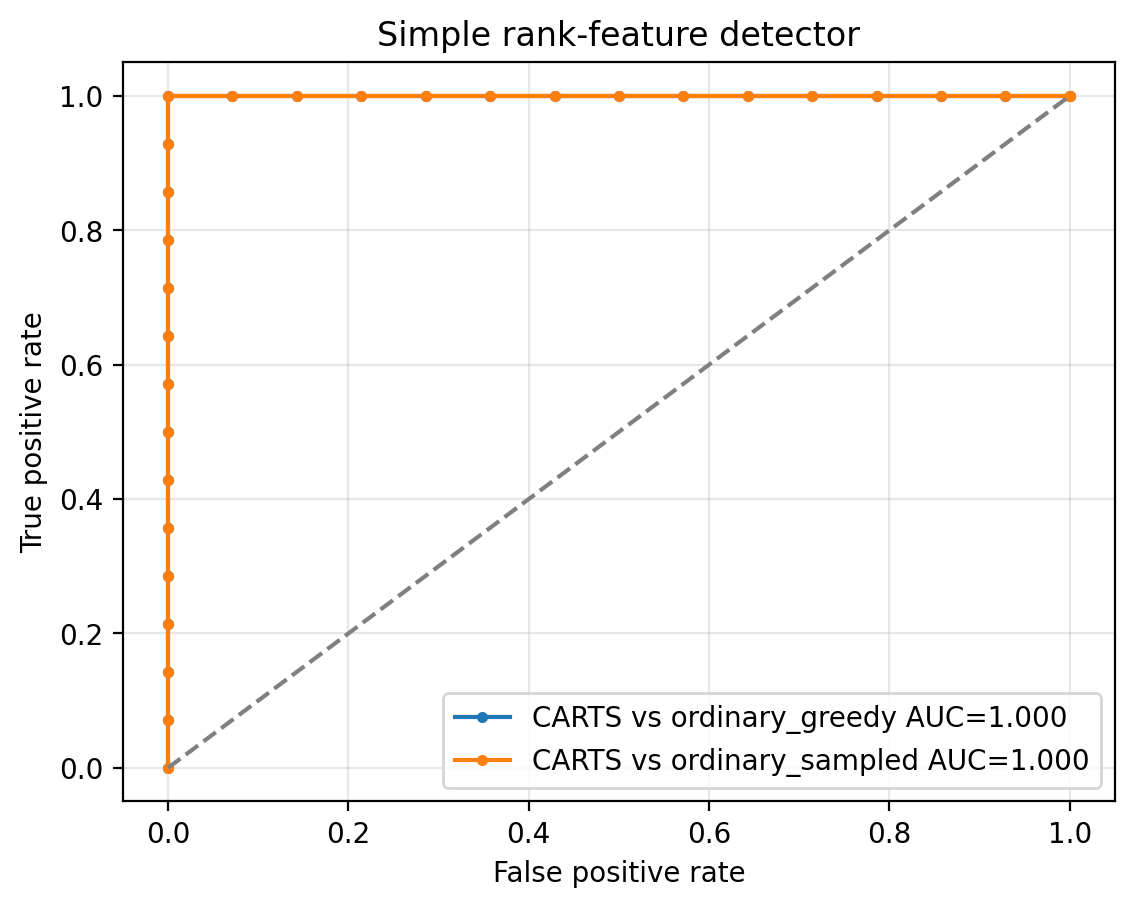

### exp2_mean_log_rank_cdf.png

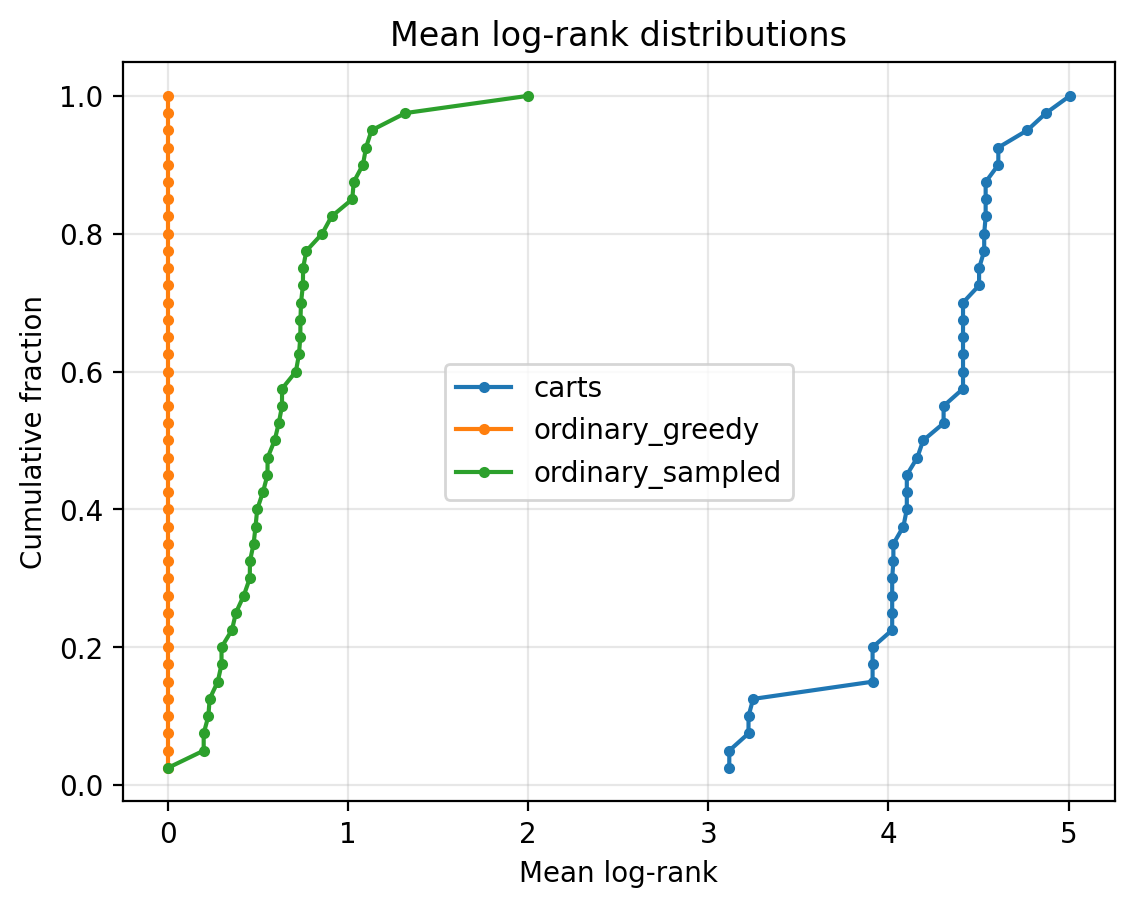

### exp2_nll_boxplot.png

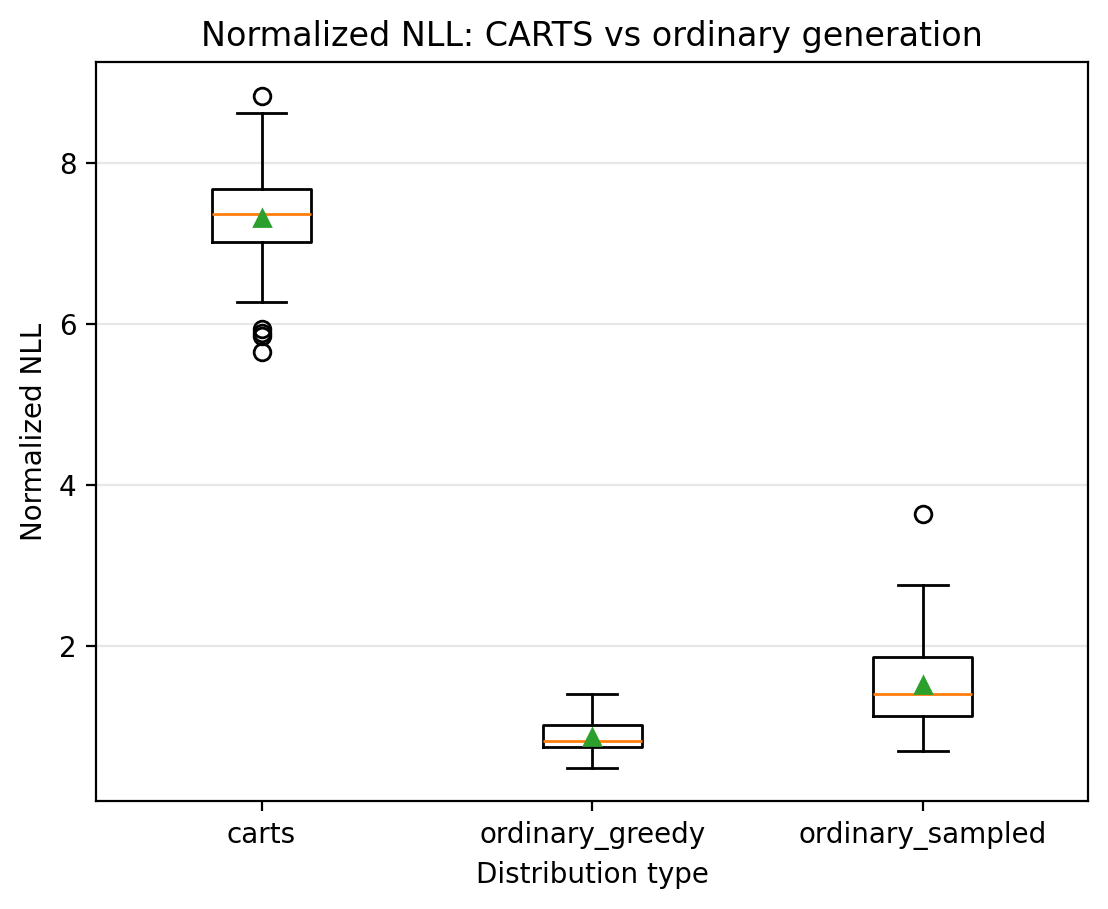

### exp2_positionwise_mean_log_rank_heatmap.png

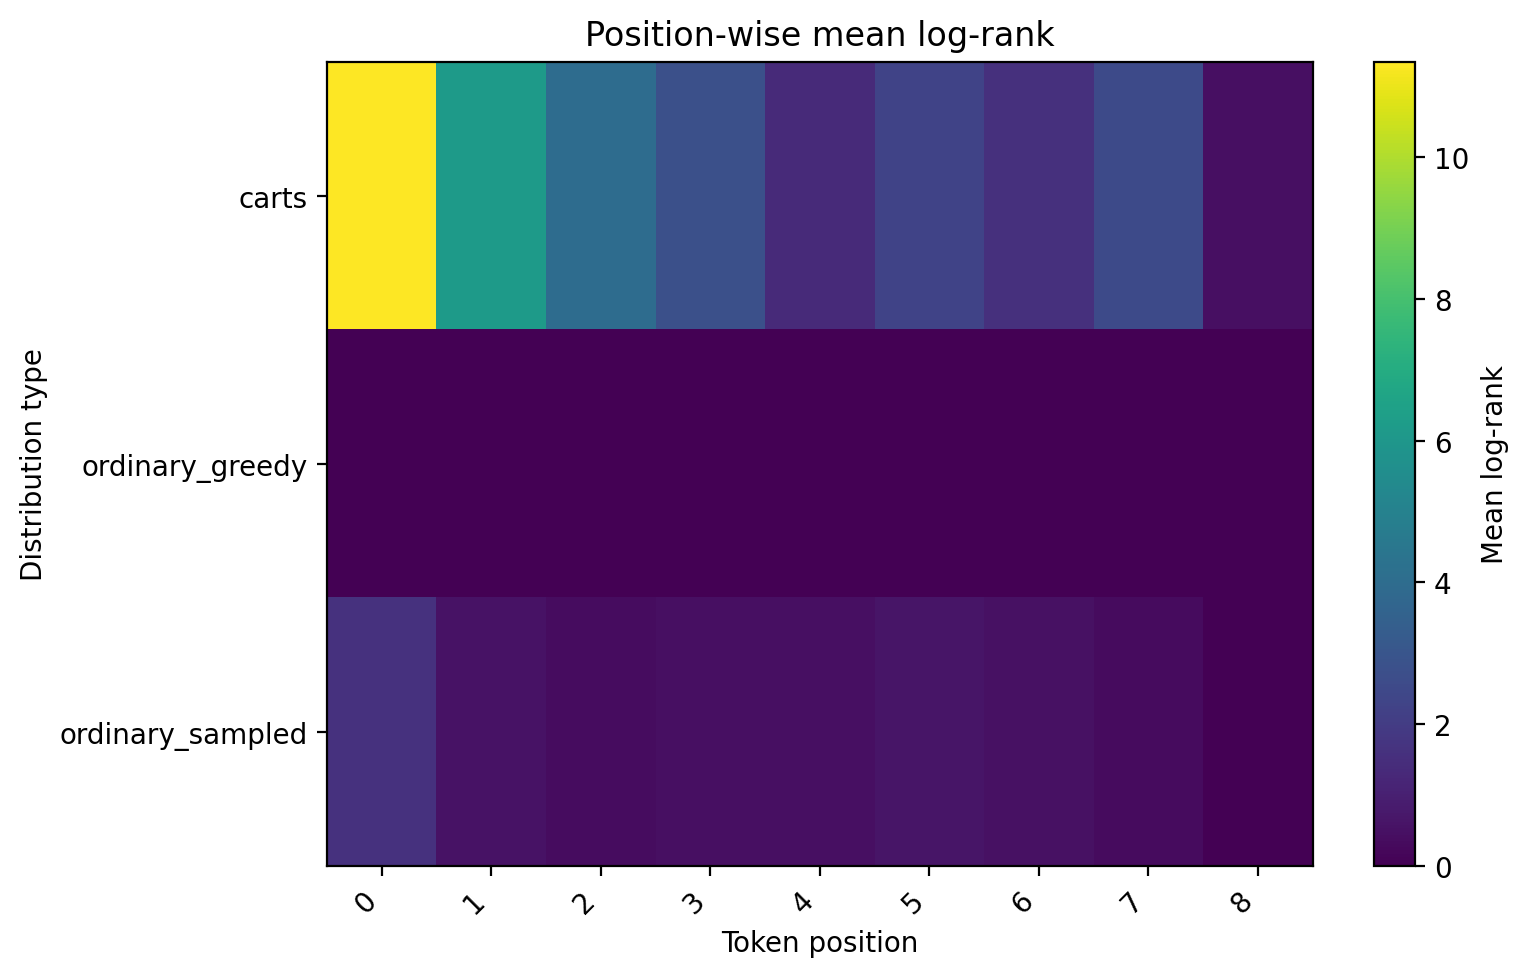

### exp2_tail_rank_vs_nll.png

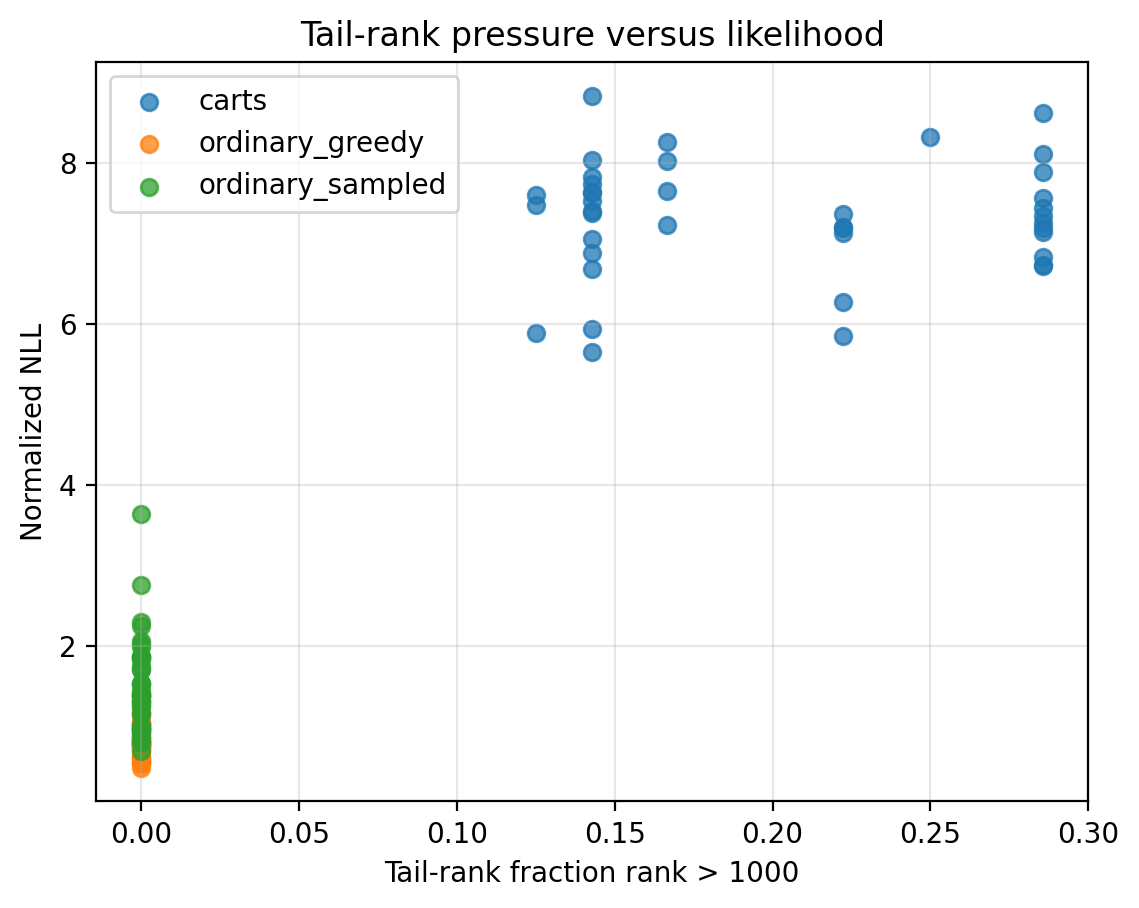

### exp3_fiber_size_histogram.png

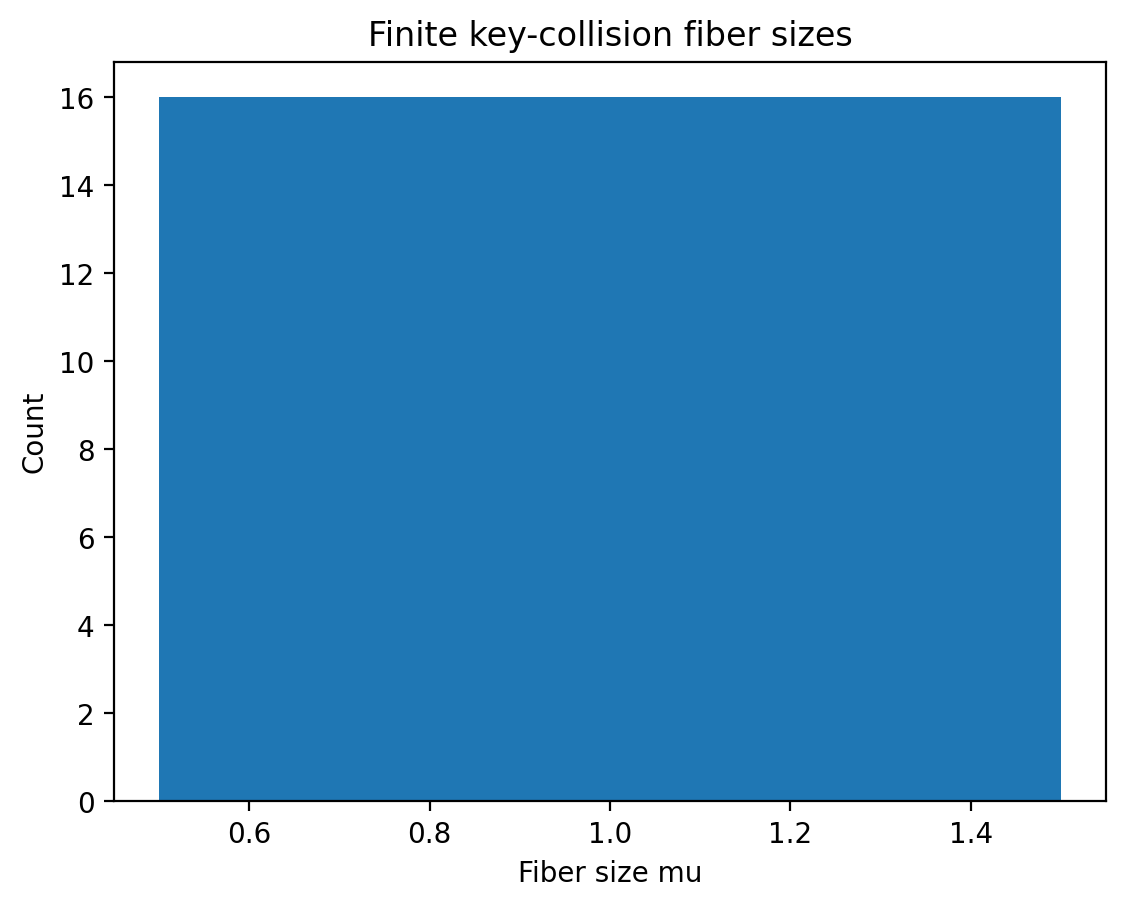

### exp3_search_time_vs_keyset_size.png

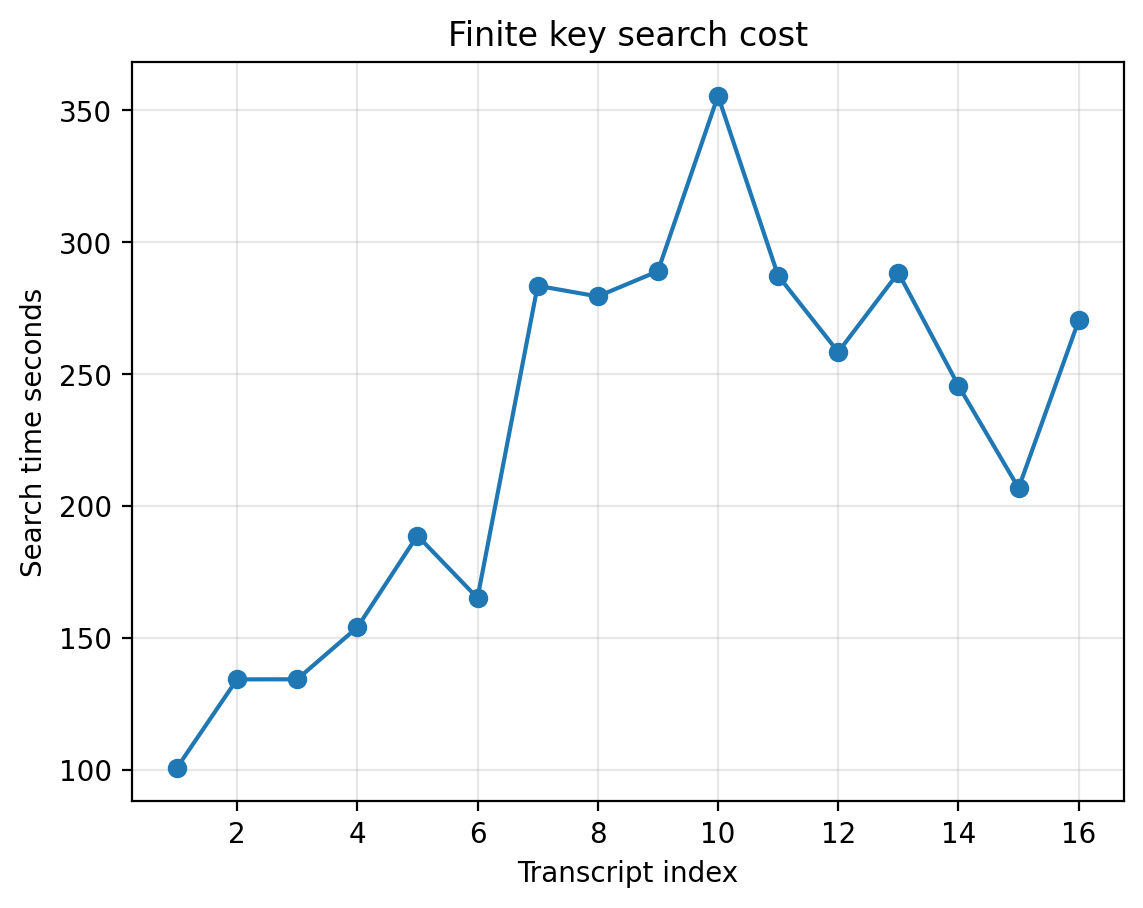

### exp3_unique_vs_collision_bar.png

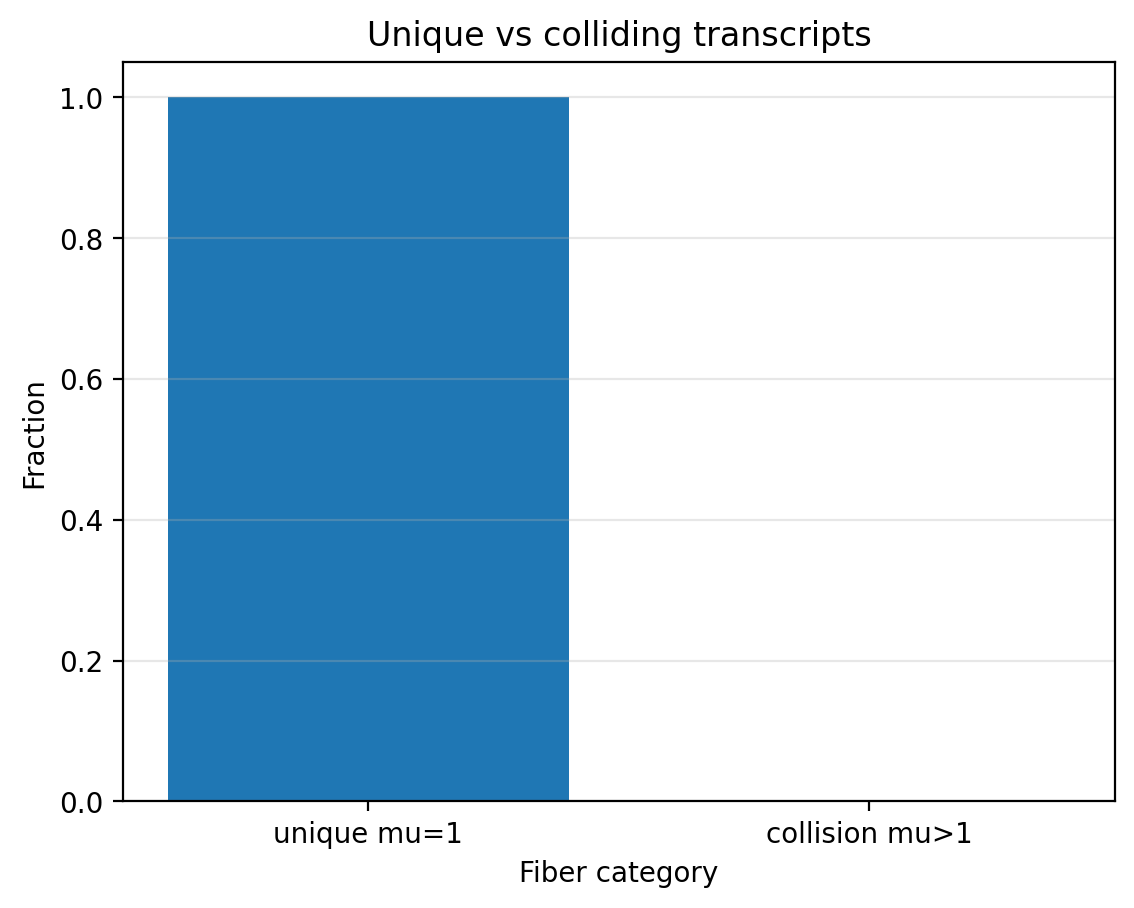

### exp4_candidate_set_size_vs_transcripts.png

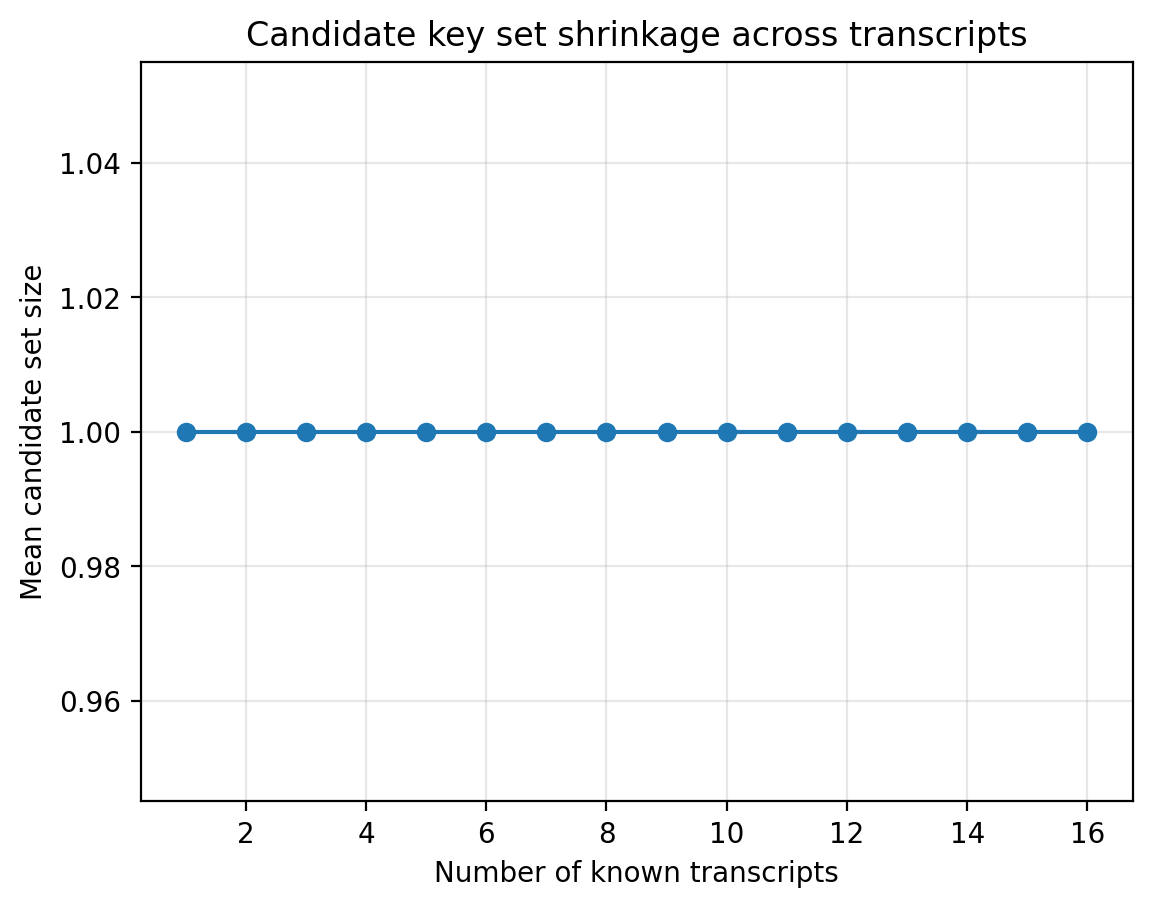

### exp5_Nk_tau_curve.png

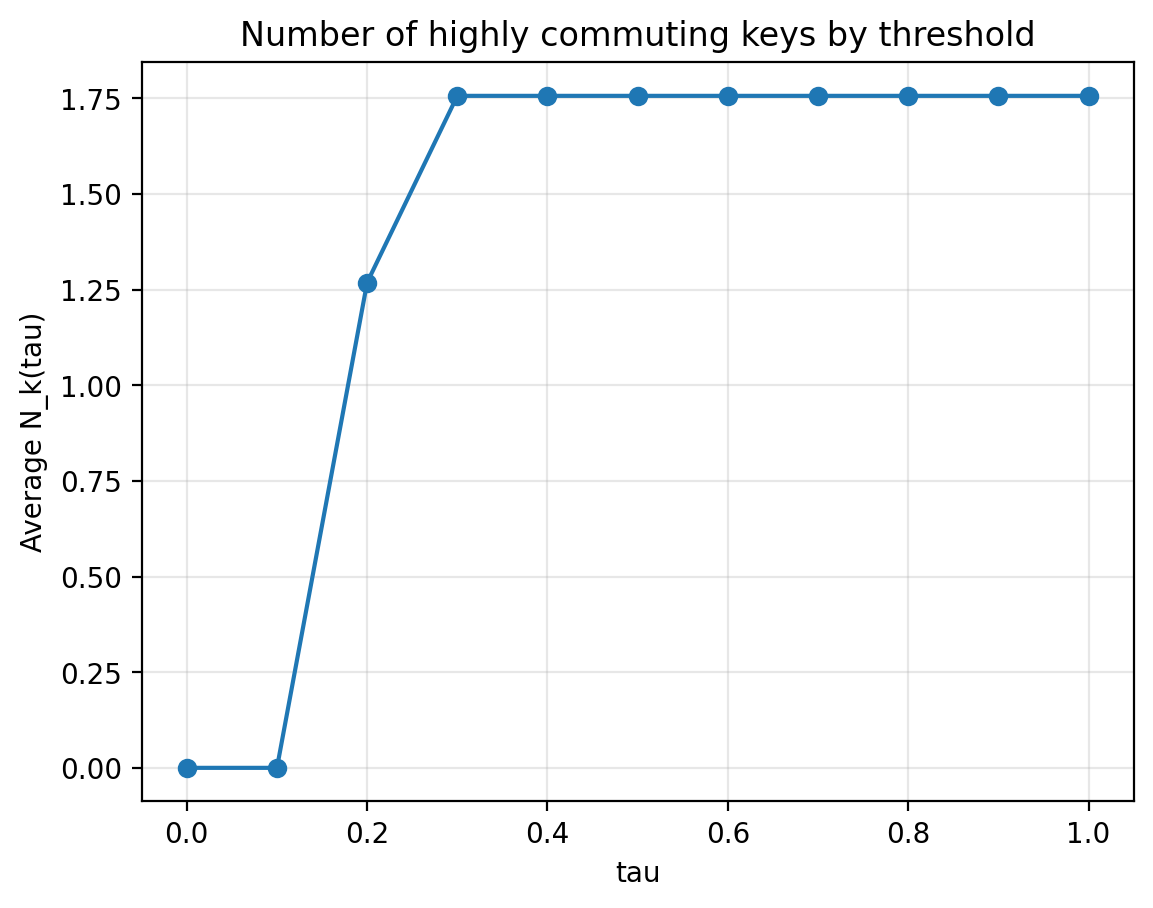

### exp5_commutation_distance_cdf.png

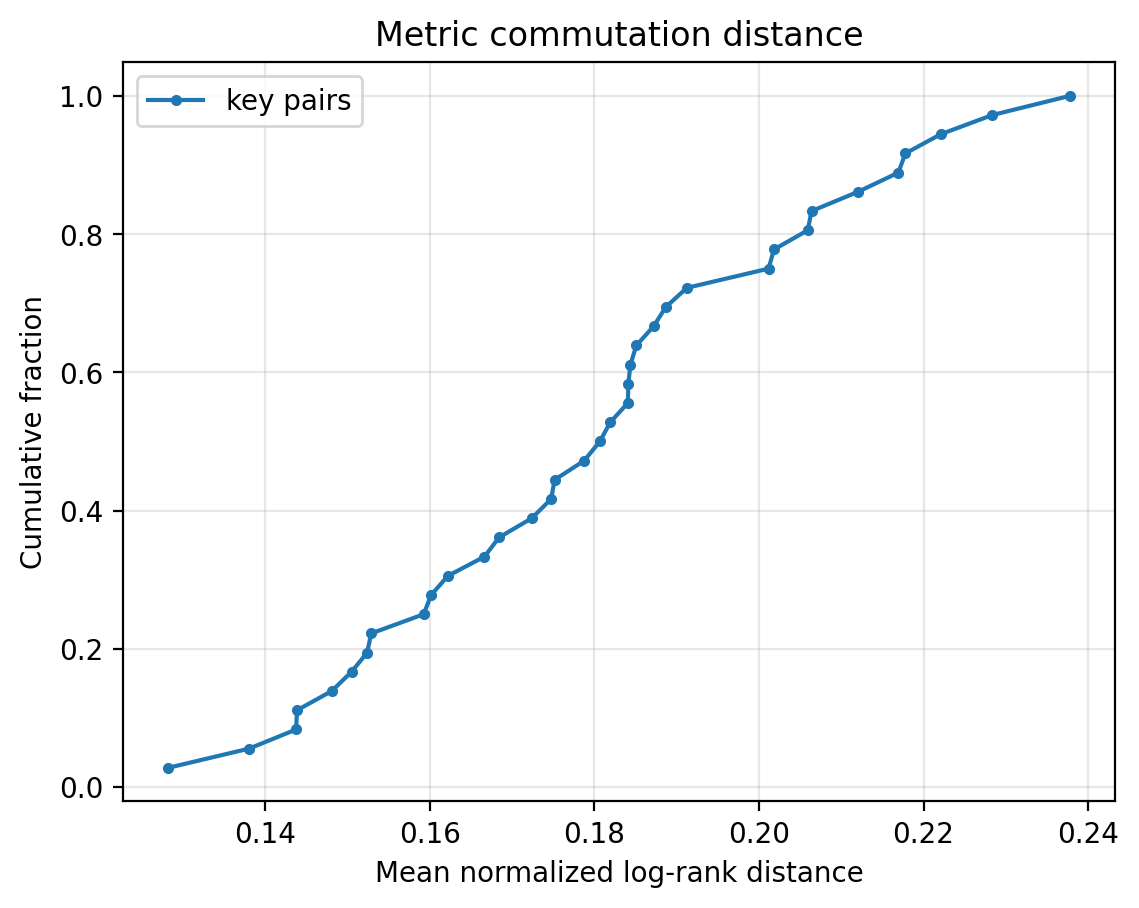

### exp5_commutation_heatmap.png

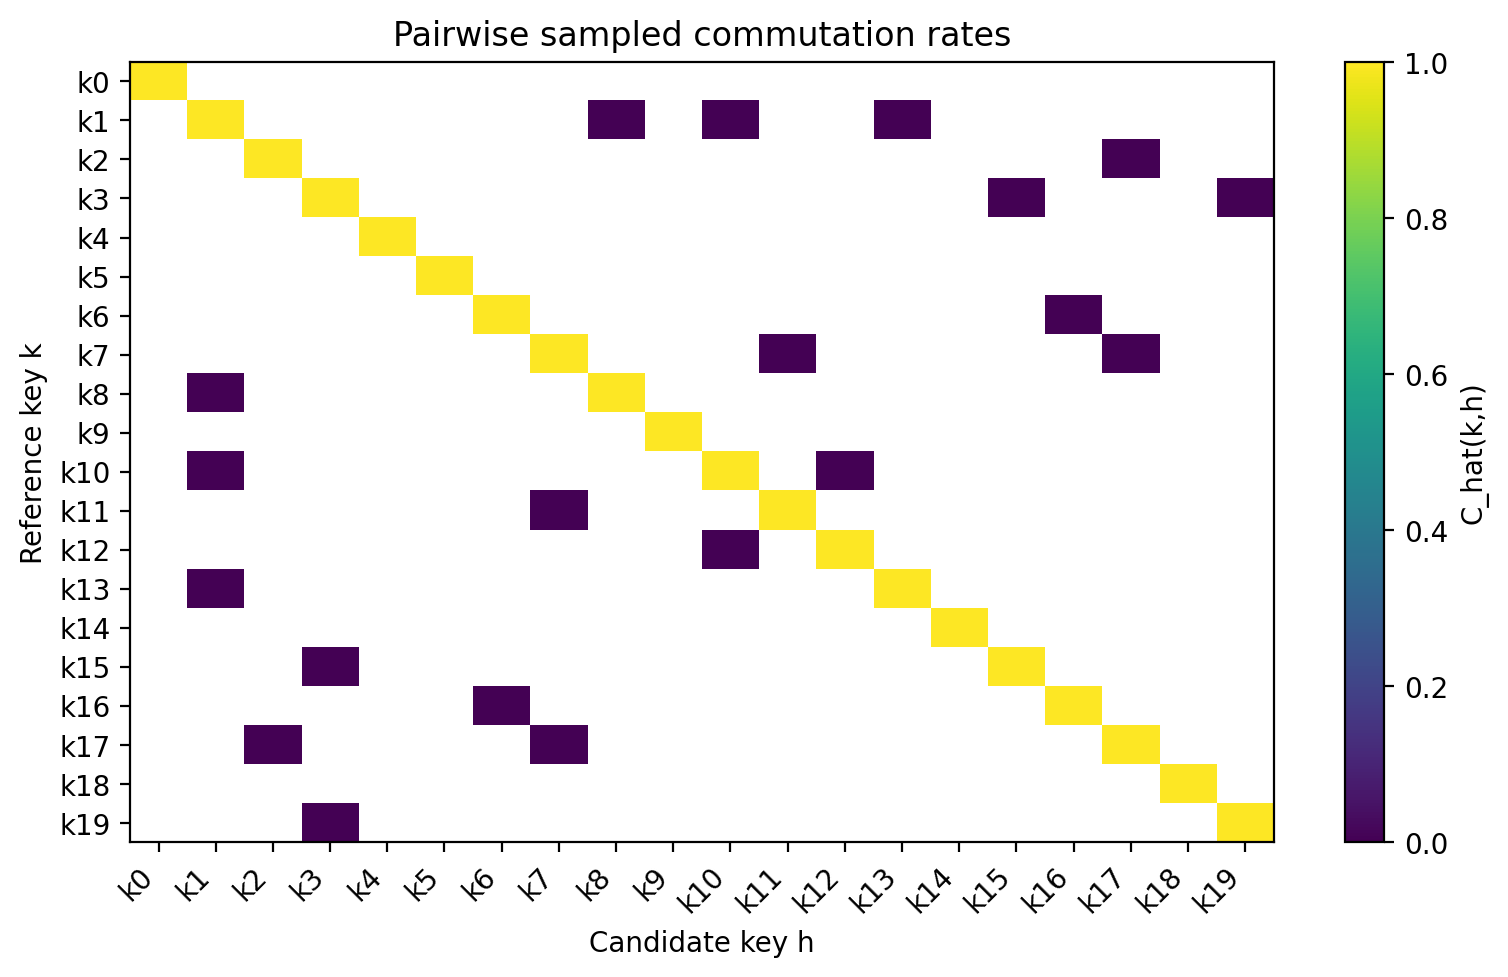

### exp5_commutation_rate_histogram.png

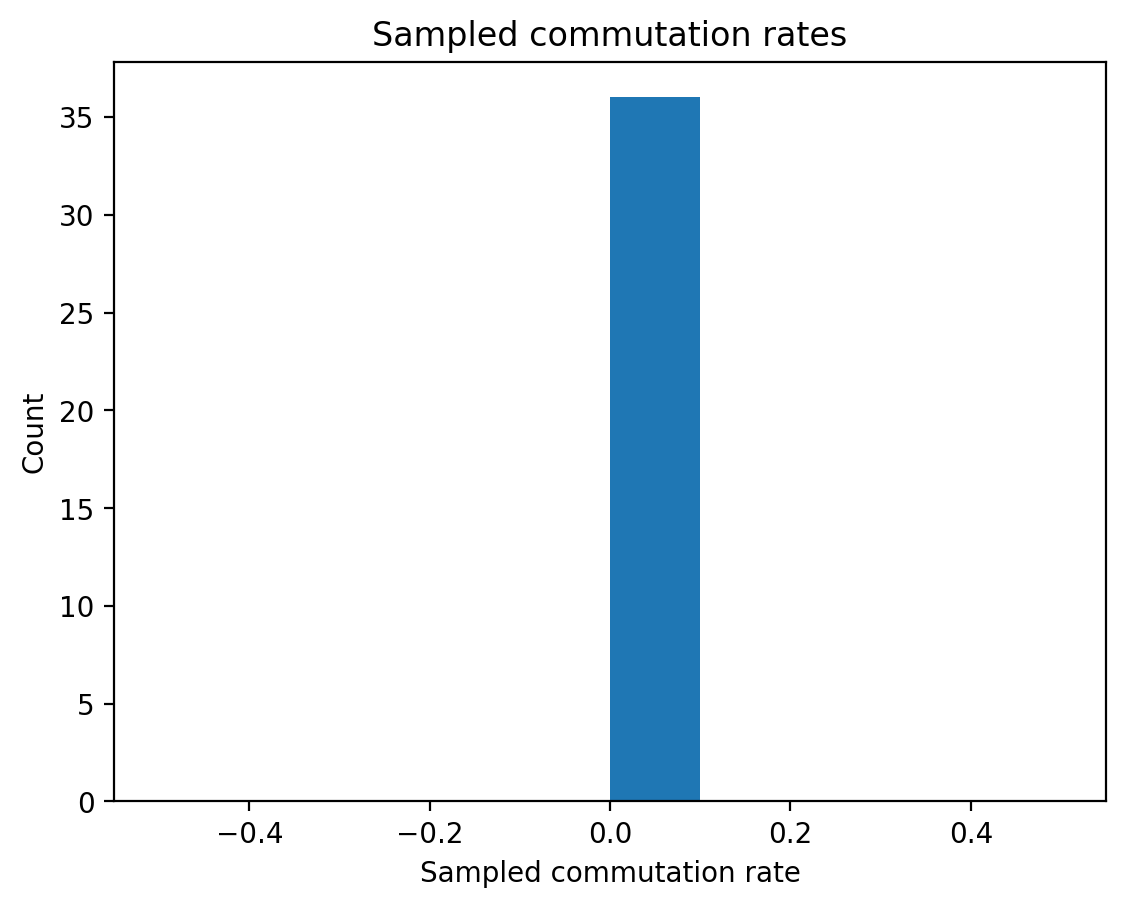

### exp6_decoded_edit_distance_by_perturbation.png

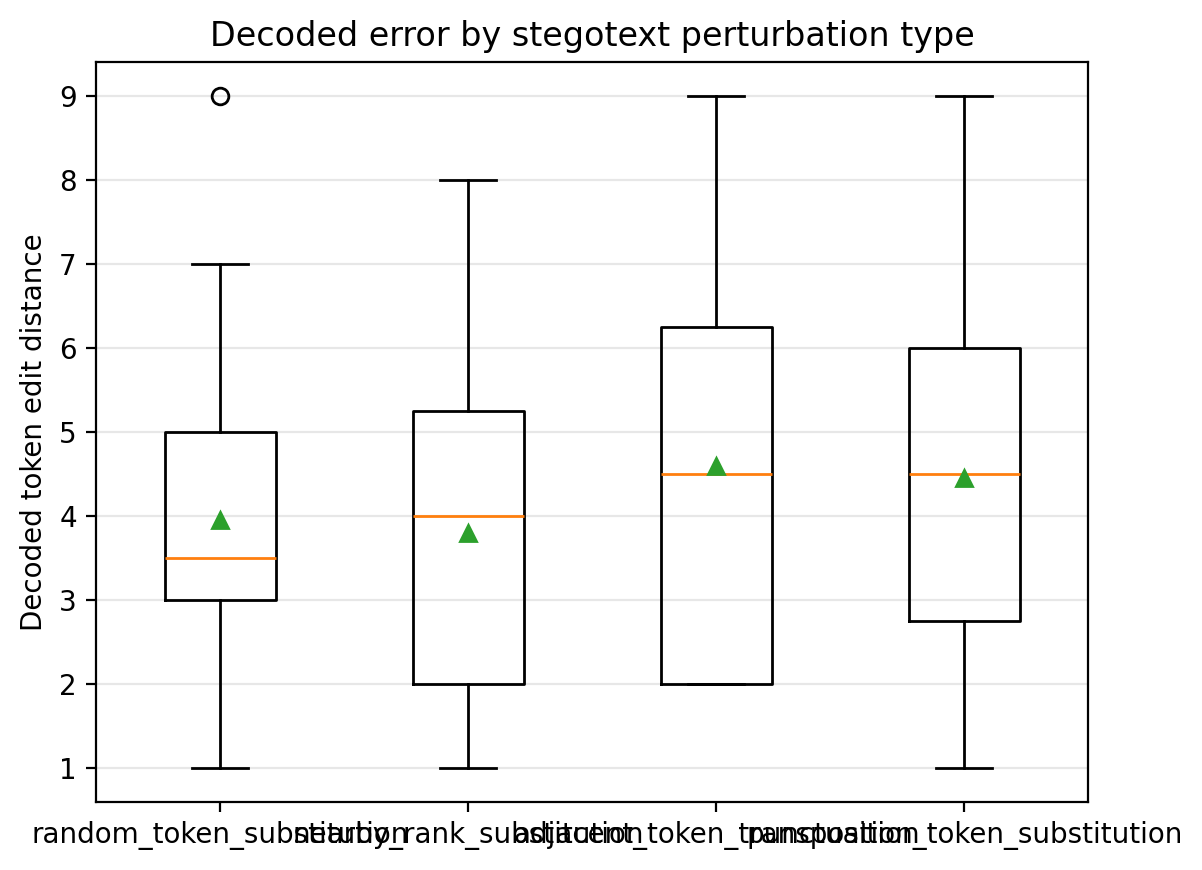

### exp6_perturb_position_vs_error_heatmap.png

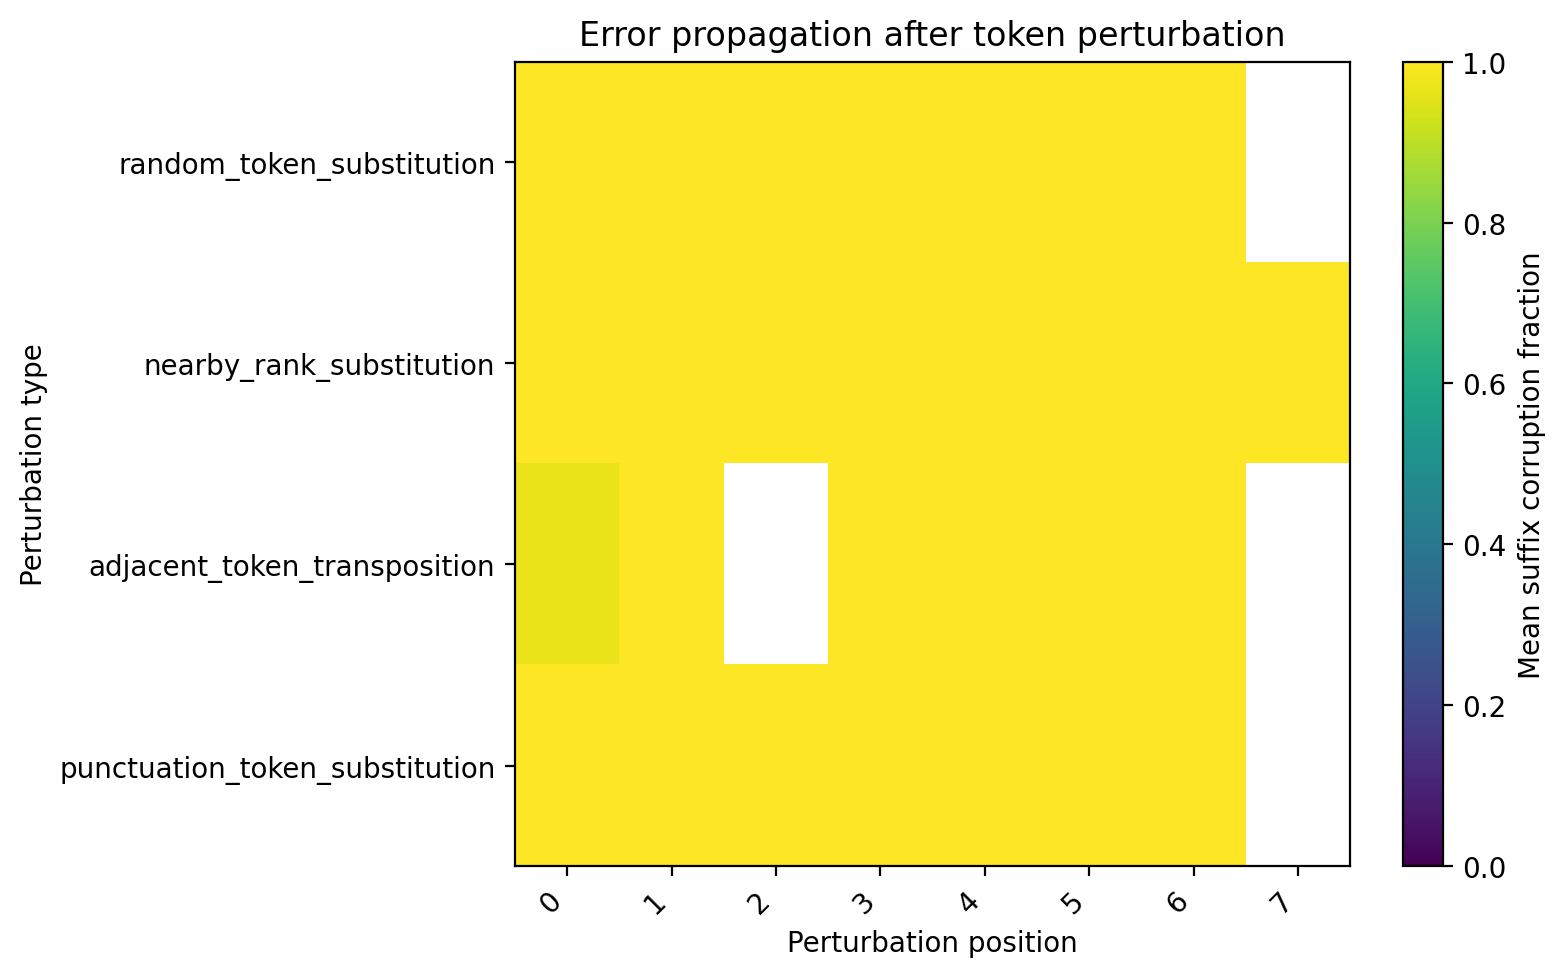

### exp6_token_agreement_after_perturbation.png

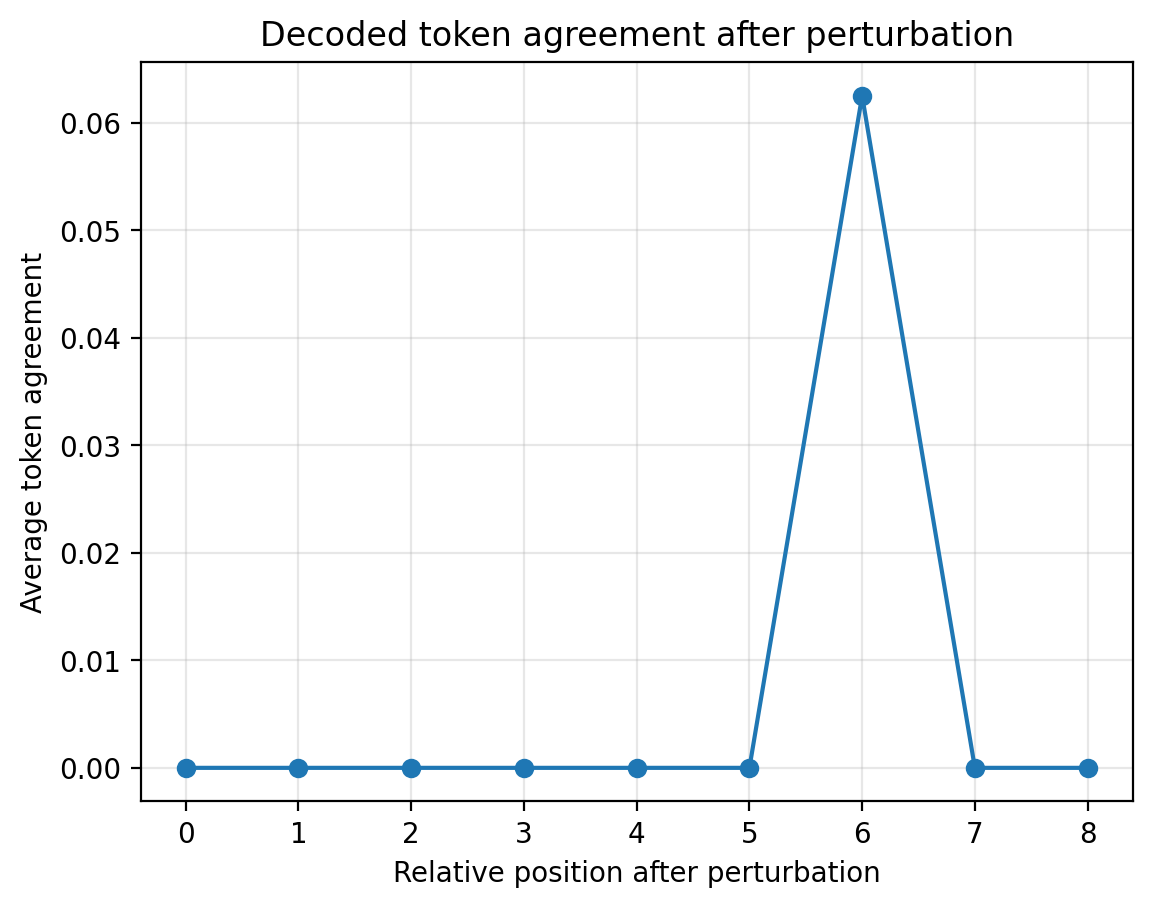

In [13]:
checklist_rows = [
    {"Theory claim": "Exact invertibility", "Experiment supporting it": "Experiment 1", "Figure/table produced": "experiment1_correctness.csv, exp1_correctness_bar.png", "Status": "pass" if RUN_NUMERIC_RESULTS.get("correctness_successes") == RUN_NUMERIC_RESULTS.get("correctness_total") else "fail", "Caveat": "Sample-level implementation verification; theorem is mathematical."},
    {"Theory claim": "Rank pressure and quality", "Experiment supporting it": "Experiment 2", "Figure/table produced": "exp2_nll_boxplot.png, exp2_mean_log_rank_cdf.png", "Status": "reported", "Caveat": "Depends on Q_k."},
    {"Theory claim": "Simple detectability", "Experiment supporting it": "Experiment 2", "Figure/table produced": "exp2_detector_roc.png", "Status": "reported", "Caveat": "Distribution-specific, not a proof of security/insecurity."},
    {"Theory claim": "Key-collision fibers", "Experiment supporting it": "Experiment 3", "Figure/table produced": "exp3_fiber_size_histogram.png, experiment3_largest_fibers.csv", "Status": "reported", "Caveat": "Finite K_adm only."},
    {"Theory claim": "Multi-transcript ambiguity", "Experiment supporting it": "Experiment 4", "Figure/table produced": "exp4_candidate_set_size_vs_transcripts.png", "Status": "reported", "Caveat": "Finite K_adm and sampled payloads."},
    {"Theory claim": "Non-commutativity", "Experiment supporting it": "Experiment 5", "Figure/table produced": "exp5_commutation_rate_histogram.png, exp5_commutation_heatmap.png", "Status": "reported", "Caveat": "No impossibility claim."},
    {"Theory claim": "Perturbation brittleness", "Experiment supporting it": "Experiment 6", "Figure/table produced": "exp6_decoded_edit_distance_by_perturbation.png", "Status": "reported", "Caveat": "Tested perturbations only."},
]
cu.write_csv(cu.TABLES_DIR / "paper_verification_checklist.csv", checklist_rows)
record_table("paper_verification_checklist.csv", "Final checklist", "Theory-claim verification checklist for the paper.", "Maps empirical outputs to paper claims.")

cu.write_csv(cu.TABLES_DIR / "figure_manifest.csv", FIGURE_MANIFEST)
cu.write_csv(cu.TABLES_DIR / "table_manifest.csv", TABLE_MANIFEST)

figure_list_md = "\n".join(f"- `{row['figure_file']}`: {row['caption_suggestion']}" for row in FIGURE_MANIFEST)
table_list_md = "\n".join(f"- `{row['table_file']}`: {row['description']}" for row in TABLE_MANIFEST)
bullets_md = "\n".join(f"- {bullet}" for bullet in PAPER_BULLETS)

cu.append_summary("Figure manifest", figure_list_md or "No figures recorded.")
cu.append_summary("Table manifest", table_list_md or "No tables recorded.")
cu.append_summary("Limitations and caveats", "\n".join([
    "- Results are under this model and tokenizer, not all LLMs.",
    "- Finite key-search results are under this finite key set only.",
    "- Greedy Q_k is a weak baseline; sampled Q_k is stronger but still not a full cover-channel model.",
    "- Detector results do not prove steganographic security or insecurity.",
    "- Exact correctness assumes identical tokenization, logits, masking, precision, and tie-breaking.",
]))
cu.append_summary("Next steps", "\n".join([
    "- If `paper_two_hour` finishes comfortably, consider a follow-up `paper_medium` run; do not launch `paper_full` automatically.",
    "- Add stronger comparison distributions for Q_k.",
    "- Add calibrated plausibility metrics before wrong-key equivocation experiments.",
    "- Test another quantization or exact model variant only as a separately labeled run.",
]))
cu.append_summary("Paper-ready paragraphs", bullets_md or "No paper-ready bullets recorded.")

cu.write_run_manifest(
    CONFIG,
    EXPERIMENT_STATUS,
    extra={
        "total_runtime_per_experiment": EXPERIMENT_RUNTIME_SECONDS,
        "numeric_results": RUN_NUMERIC_RESULTS,
        "figure_count": len(FIGURE_MANIFEST),
        "table_count": len(TABLE_MANIFEST),
        "time_budget_adjustments": BUDGET_ADJUSTMENTS,
        "total_elapsed_runtime_seconds": elapsed_run_seconds(),
        "max_runtime_hours": CONFIG.get("max_runtime_hours"),
        "estimated_runtime_seconds_from_previous": CONFIG.get("estimated_runtime_seconds_from_previous"),
        "estimated_runtime_components_seconds_from_previous": CONFIG.get("estimated_runtime_components_seconds_from_previous", {}),
    },
)

print("CSV files:")
for path in cu.list_saved_tables():
    print(" -", cu.relative_path(path))
print("Markdown summary:", cu.relative_path(cu.SUMMARY_PATH))
print("Paper-ready result bullets:")
for bullet in PAPER_BULLETS:
    print("-", bullet)
show_rows(checklist_rows, n=len(checklist_rows))

if Image is not None:
    for fig_path in cu.list_saved_figures():
        display(Markdown(f"### {fig_path.name}"))
        display(Image(filename=str(fig_path)))
